In [1]:
import glob
import sys
import os
import json
import bioframe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from config import *
import h5py
from scipy.stats import truncnorm
from OccupancyInputCTCF.utils.analysis import calculate_frip
from cooltools.lib.numutils import adaptive_coarsegrain
import multiprocessing as mp
from functools import partial
# Add custom library path
sys.path.append('/home1/rahmanin/start/polychrom/projects/Site_wise_occupancy/OccupancyInputCTCF/')

# Import utility modules
import OccupancyInputCTCF.utils as util
import OccupancyInputCTCF.utils.plots as mplot
import OccupancyInputCTCF.utils.convert as convert
import OccupancyInputCTCF.utils.ml as ml
import OccupancyInputCTCF.utils.makeparams as params
import OccupancyInputCTCF.utils.One_d_simulation as simulation
import OccupancyInputCTCF.utils.md_simulation as mdsimulation
import OccupancyInputCTCF.utils.cmap_utils as utils_s
import warnings
warnings.filterwarnings('ignore')
import time
start = time.time()



/home1/rahmanin/start/polychrom/projects/Site_wise_occupancy/OccupancyInputCTCF/OccupancyInputCTCF/utils/snippet.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_dataframe['mid'] = (region_dataframe.end + region_dataframe.start) / 2


this is file name folder_face_1.0_back_0.0_Clife_300_Cof_180_life_660.0_slife_660.0_birth_0.1_pause_0.9_sep_74_site_10_replica_10_vel_1_steps_20
{'CTCF_facestall': [1.0], 'CTCF_backstall': [0.0], 'CTCF_lifetime': [300], 'CTCF_offtime': [180], 'LEF_lifetime': [660.0], 'LEF_stalled_lifetime': [660.0], 'LEF_birth': [0.1], 'LEF_pause': [0.9], 'LEF_separation': 74, 'sites_per_monomer': 10, 'number_of_replica': 10, 'velocity_multiplier': 1, 'steps': 20}


/home1/rahmanin/.conda/envs/openmm-env/lib/python3.7/site-packages/cooltools/lib/numutils.py:11: FutureWarning: The `cooler.tools` module is deprecated in v0.9 and will be removed in v0.10. Use `cooler.parallel` instead.
  from ._numutils import (
/home1/rahmanin/.conda/envs/openmm-env/lib/python3.7/site-packages/cooltools/api/expected.py:14: FutureWarning: The `cooler.tools` module is deprecated in v0.9 and will be removed in v0.10. Use `cooler.parallel` instead.
  from cooler.tools import partition


### calculating number of ctcf per 10 mbp

In [2]:
genome_length = 3*2.7 # Gbp
tot_motifs = 55073
occup_mean = 0.33182353
ctcf_tot_number = 217000
bound_fraction = 0.5
occup_mean_p = (ctcf_tot_number/3)*bound_fraction/tot_motifs
multiplication = occup_mean_p/occup_mean
ctcf_per_10_meg = (10*1e6 / (genome_length *1e9) * bound_fraction * ctcf_tot_number)# / occup_mean
ctcf_per_10_meg

133.95061728395058

In [3]:
occup_mean_p

0.6567041320913454

In [4]:
# =================== WORKFLOW ===========================
print("Starting workflow...")

# Step 1: Preprocessing bed files in selected region
print("Step 1: Preprocessing...")
ctcf_bed_file = f'processing/{REGION}.csv'
ctcf_bed_df.to_csv(ctcf_bed_file, index=False)
print("Step 1 complete. Output:", ctcf_bed_df)

# Step 2: Predicting Occupancy Rate
print("Step 2: Predicting Occupancy Rate...")
if USE_PREDICTED_OCCUPANCY:
    ctcf_occup_bed_df = ml.predict_ctcf_occupancy(ctcf_bed_file)
else:
    ctcf_occup_bed_df = convert.convert_ctcf_occupancy(ctcf_bed_df, ctcf_peaks)
#print("Step 2 complete. Output:", ctcf_occup_bed_df)

# Step 3: Refining Occupancy for Overlapping Sites
print("Step 3: Refining Occupancy...")
refined_occupancy = convert.get_refined_occupancy(ctcf_occup_bed_df, REGION)
#print("Step 3 complete. Output:", refined_occupancy)

# Step 4: Generating Barrier List with Occupancy and Lifetimes
print("Step 4: Generating Barrier List...")
CTCF_left_positions, CTCF_right_positions, ctcf_loc_list, ctcf_lifetime_list, ctcf_offtime_list = convert.get_ctcf_list(
    refined_occupancy, PARAMDICT, insert_on='bound_time')
#print("Step 4 complete. Right barriers:", CTCF_right_positions, "Left barriers:", CTCF_left_positions)



Starting workflow...
Step 1: Preprocessing...
Step 1 complete. Output:     chrom     start       end strand         mid
0    chr1  30259567  30259923      -  30259745.0
1    chr1  30584869  30585215      -  30585042.0
2    chr1  30596155  30596483      -  30596319.0
3    chr1  30696376  30696696      -  30696536.0
4    chr1  30700404  30700735      +  30700569.5
..    ...       ...       ...    ...         ...
150  chr1  37419284  37420006      +  37419645.0
151  chr1  37448323  37448784      +  37448553.5
152  chr1  37466652  37466949      +  37466800.5
153  chr1  37479077  37479455      +  37479266.0
154  chr1  33670365  33670639      -  33670502.0

[155 rows x 5 columns]
Step 2: Predicting Occupancy Rate...
Step 3: Refining Occupancy...
Step 4: Generating Barrier List...


In [5]:
bind_sites_filepath = 'tutorials/data/sonmezer_dataset_CTCT_binding.sites.filtered.mm10.tsv'
bind_freqs_filepath = 'tutorials/data/binding.frequencies.tsv'
ref_genome_filepath = '/project/fudenber_735/genomes/mm10/mm10.fa'

#ref_genome = pysam.FastaFile(ref_genome_filepath)
bind_sites = pd.read_table(bind_sites_filepath)
bind_freqs = pd.read_table(bind_freqs_filepath)

### random selection of ctcf occupancies

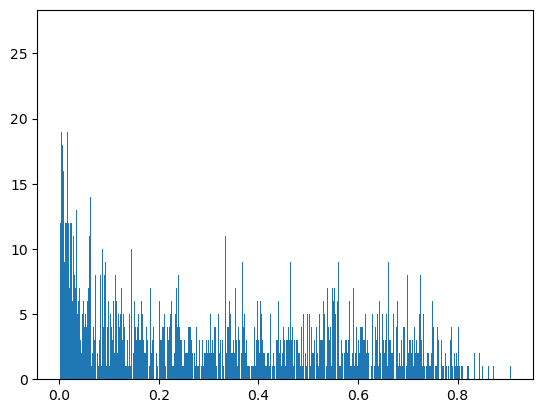

In [6]:
df = pd.read_csv(bind_freqs_filepath, sep = '\t')
ctcf_occup_exp = df[df['biological.state']=='Bound']
ctcf_occup_rand = np.random.choice( (ctcf_occup_exp['Freqs'].values), (3000,), replace=True)
plt.hist(ctcf_occup_rand, bins= 1000)
plt.show()

In [7]:
max(ctcf_occup_rand)

0.906976744186046

In [8]:
ctcf_occup_exp['Freqs'].mean()

0.32704447071602344

In [9]:
#ref_genome = pysam.FastaFile(ref_genome_filepath)
bind_sites = pd.read_table(bind_sites_filepath)
bind_freqs = pd.read_table(bind_freqs_filepath)
df = pd.read_csv(bind_freqs_filepath, sep = '\t')
ctcf_occup_exp = df[df['biological.state']=='Bound']


# filtering sites with provided all three frequencies
site_filter = []
for tfbs in bind_freqs['TFBS_cluster'].unique():
       if len(bind_freqs[bind_freqs['TFBS_cluster'] == tfbs]) == 3:
            site_filter.append(tfbs)              
bind_sites = bind_sites[bind_sites.rownames.isin(site_filter)]
bind_sites_revised= bind_sites.rename(columns={'rownames':'TFBS_cluster'})
bind_freqs_dtf = bind_freqs[bind_freqs.TFBS_cluster.isin(site_filter)]
bind_freqs_pivot = bind_freqs_dtf.pivot_table(index='TFBS_cluster', columns='biological.state', values='Freqs', aggfunc='first')
bind_freqs_pivot.reset_index(inplace=True)
bind_freqs_pivot = bind_freqs_pivot[['TFBS_cluster','Accessible','Bound', 'Nucleosome.occupied']]
states = bind_freqs['biological.state'].unique()
#bind_freqs_pivot
binds_sites_freqs = pd.merge(bind_sites_revised, bind_freqs_pivot, on='TFBS_cluster', how='left')
binds_sites_freqs.to_csv('sites_with_freqs.tsv',sep='\t')

### making labels
frequency_columns = ['Accessible', 'Bound', 'Nucleosome.occupied']

# Convert the selected columns to a NumPy array
experiment_occup = binds_sites_freqs[['chrom','start','end','Bound']]
experiment_occup['true_occupancy']=experiment_occup['Bound']
experiment_occup

,chrom,start,end,Bound,true_occupancy
0,chr1,9541413,9541431,0.226913,0.226913
1,chr1,9541469,9541487,0.271565,0.271565
2,chr1,9545334,9545352,0.214724,0.214724
3,chr1,11140105,11140123,0.052430,0.052430
4,chr1,13500664,13500682,0.032338,0.032338
...,...,...,...,...,...
8919,chr19,60144531,60144549,0.574713,0.574713
8920,chr19,60161071,60161089,0.349206,0.349206
8921,chr19,60310788,60310806,0.341463,0.341463
8922,chr19,60341678,60341696,0.600000,0.600000


In [10]:
experiment_occup['true_occupancy'].max()

0.950549450549451

In [11]:
experiment_occup['true_occupancy'].mean()

0.3265119666280951

### filtering true occupancy

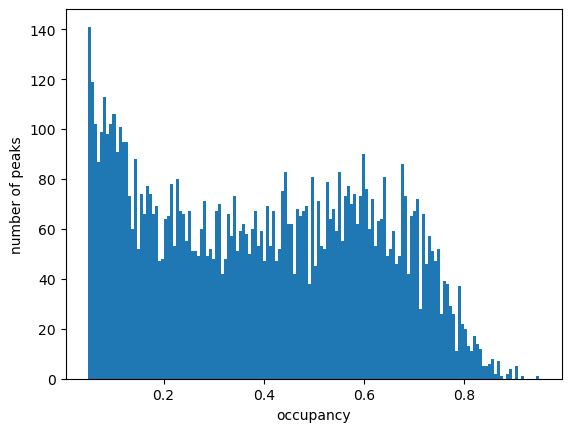

In [12]:
experiment_occup_mod = experiment_occup.query('true_occupancy >=0.05')
ctcf_occup_rand = np.random.choice( (experiment_occup_mod['true_occupancy'].values), (8144,), replace=True)
plt.hist(ctcf_occup_rand, bins= 150)
plt.ylabel('number of peaks')
plt.xlabel('occupancy')
plt.show()

In [13]:
occup_mean_rand = np.mean(experiment_occup_mod['true_occupancy'])
occup_mean_rand
occup_exp = 0.65
unbound_mean = 330*(1-occup_exp)/occup_exp
multiplication = occup_mean_rand/occup_exp
bound_mean = occup_mean_rand*unbound_mean/(1-occup_mean_rand)
bound_mean

117.15284807848296

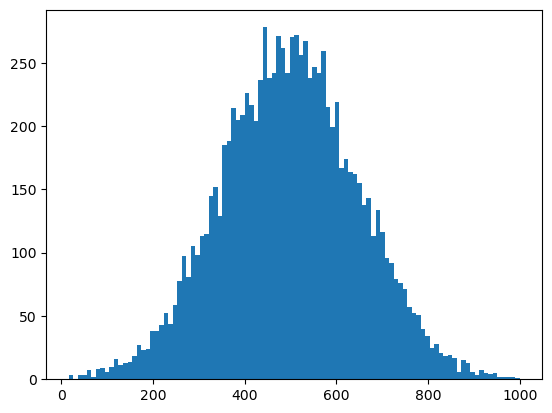

In [15]:
from scipy.stats import truncnorm

# Parameters
mean = 500
std_dev = 150  # controls spread
lower = 10
upper =mean

# Convert bounds to truncnorm's standard normal form
a = (lower - mean) / std_dev
b = (upper ) / std_dev

# Draw a sample
s = []
for i in range(10000):
    random_time = truncnorm.rvs(a, b, loc=mean, scale=std_dev)
    s.append(random_time)
plt.hist(s, bins=100)
plt.show()

In [16]:
ctcf_per_10_meg

133.95061728395058

### spesifying occupancy rates from Sonmezer

In [17]:
ctcf_random_list_num = np.random.choice(np.arange(0, 30000), size=5000, replace=False)
CTCF_right_positions_list = []
CTCF_left_positions_list = []
CTCF_occup_list = []
occup_sum = 0
i = 0 
while occup_sum < ctcf_per_10_meg/(3/2):
    CTCF_right_positions_list.append(ctcf_random_list_num[i])
    CTCF_occup_list.append(ctcf_occup_rand[i])#ctcf_occup_exp['Freqs'].mean())#
    occup_sum += ctcf_occup_rand[i]#ctcf_occup_exp['Freqs'].mean()#
    i += 1
    CTCF_left_positions_list.append(ctcf_random_list_num[i])
    CTCF_occup_list.append(ctcf_occup_rand[i])#ctcf_occup_exp['Freqs'].mean())#
    occup_sum += ctcf_occup_rand[i]#ctcf_occup_exp['Freqs'].mean()#
    i += 1
    
ctcf_loc_list = CTCF_right_positions_list + CTCF_left_positions_list
CTCF_right_positions = np.array(CTCF_right_positions_list)
CTCF_left_positions = np.array(CTCF_left_positions_list)    

In [18]:
max(CTCF_occup_list)

0.85513608428446

In [19]:
len(ctcf_loc_list)

222

### modifying initial average unbound time 

In [20]:
occup_mean_rand = np.mean(CTCF_occup_list)
occup_mean_rand
occup_exp = 0.65
unbound_mean = 330*(1-occup_exp)/occup_exp
multiplication = occup_mean_rand/occup_exp
bound_mean = occup_mean_rand*unbound_mean/(1-occup_mean_rand)
print(bound_mean,unbound_mean)

120.0678457804085 177.69230769230765


### determining the new bound and unbound list with a random distribution around the average

In [21]:
CTCF_occup_list = np.array(CTCF_occup_list)
ctcf_lifetime_list_ = CTCF_occup_list * unbound_mean / (1 - CTCF_occup_list)#  + pseudo) for scenario with ctcf occupancy up to 1
s = []

for i in range(len(ctcf_lifetime_list_)): 
    mean = ctcf_lifetime_list_[i]
    std_dev = ctcf_lifetime_list_[i]/300
    upper = mean
    a = (3 - mean) / std_dev
    b =  upper / std_dev
    random_value = truncnorm.rvs(a, b, loc=mean, scale=std_dev)
    s.append(random_value)
ctcf_lifetime_list = ctcf_lifetime_list_ + np.array(s)
ctcf_offtime_list = ctcf_lifetime_list*((1-CTCF_occup_list)/CTCF_occup_list)

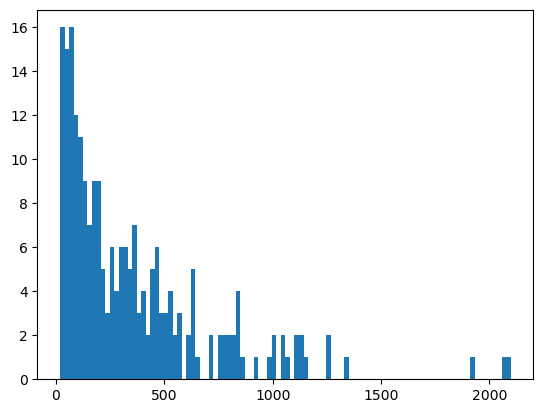

In [22]:
plt.hist(ctcf_lifetime_list, bins= 100)
plt.hist(ctcf_offtime_list, bins = 38)
plt.show()

In [23]:
print(np.mean(ctcf_lifetime_list), np.min(ctcf_lifetime_list), np.max(ctcf_lifetime_list))

354.9038588718472 18.808503866127953 2098.877873117003


### if you want reflection of occupancy on unbound time

In [24]:
CTCF_occup_list = np.array(CTCF_occup_list)
ctcf_offtime_list_ = (1-CTCF_occup_list) * bound_mean / (CTCF_occup_list)#  + pseudo) for scenario with ctcf occupancy up to 1
s = []

for i in range(len(ctcf_lifetime_list_)): 
    mean = ctcf_offtime_list_[i]
    std_dev = ctcf_offtime_list_[i]/300
    upper = mean
    a = (3 - mean) / std_dev
    b =  upper / std_dev
    random_value = truncnorm.rvs(a, b, loc=mean, scale=std_dev)
    s.append(random_value)
ctcf_offtime_list = ctcf_offtime_list_#+np.array(s)
ctcf_lifetime_list = ctcf_offtime_list* CTCF_occup_list/(1-CTCF_occup_list)

### CTCF with maximum distance between each other

In [25]:
# Define total range and number of samples
start = 0
end = 30000
n_samples = 850

# Generate evenly spaced indices, then jitter them slightly to maintain randomness
base = np.linspace(start, end, n_samples, endpoint=False, dtype=int)
jitter = np.random.randint(-3, 3, size=n_samples)  # small random jitter
ctcf_random_list_num = np.clip(base + jitter, start, end - 1)


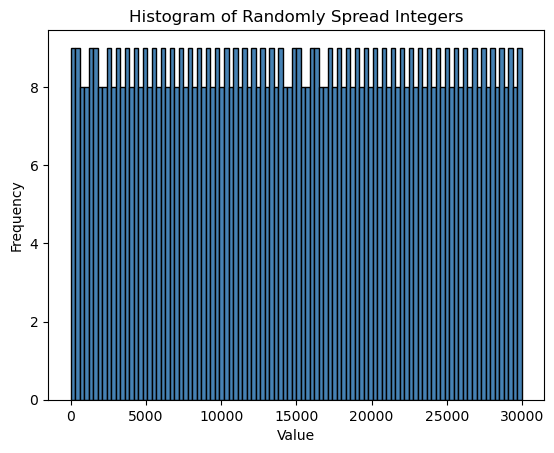

In [26]:
import matplotlib.pyplot as plt

plt.hist(ctcf_random_list_num, bins=100, color='steelblue', edgecolor='black')
plt.title("Histogram of Randomly Spread Integers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [6]:
# Define the file pattern
file_pattern = "data/Rad21_vs_ctcf_reads_random_mod_a_w_chr1*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)
print(len(csv_files))
# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_newtot.csv', index=False)

16


In [78]:
# Define the file pattern
file_pattern = "data/Rad21_vs_ctcf_reads_random_mod_a_w_conf_chr1*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)
print(len(csv_files))
# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_conf_newtot.csv', index=False)

16


In [10]:
file = df_merged
rounded_file = file.round()

# Add derived columns
rounded_file['reads'] = rounded_file['Rad21'] 
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

#print(subset)
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

print(f'Max reads is {max_read} and ctcf_reads is {ctcf_max}')
print(f'Median reads value: {median_read}')
print(f'Corresponding ctcf_reads value: {ctcf_for_median_read}')

Max reads is 30516 and ctcf_reads is 6168.0
Median reads value: 10463.0
Corresponding ctcf_reads value: 6391.0


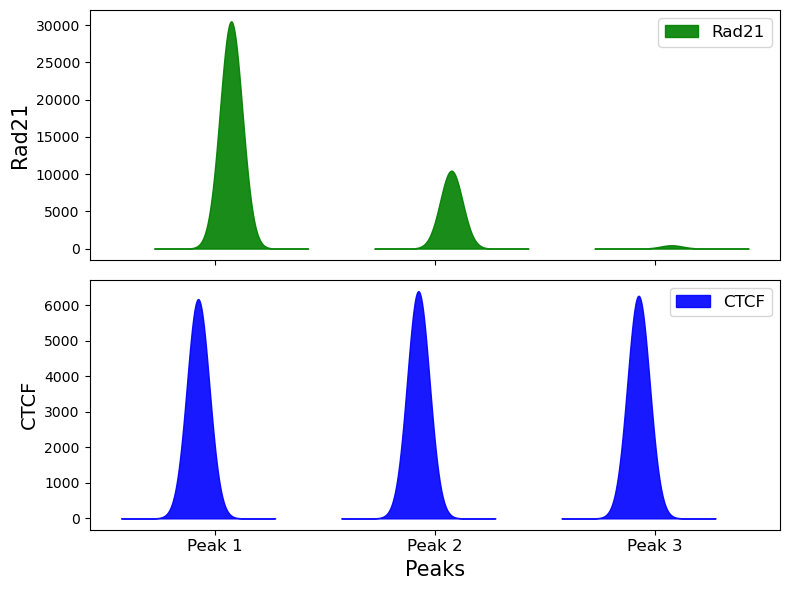

In [11]:
# Data
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]
x = np.arange(len(ctcf_s))

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

sigma = 0.051  # Constant width
offset = 0.075

# Plot Rad21 (top)
for i, val in enumerate(rad_s):
    mu = x[i] + offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax1.fill_between(x_fine, y, 0, color='green', alpha=0.9, label='Rad21' if i == 0 else "")
ax1.set_ylabel('Rad21', fontsize=15)
ax1.legend(fontsize=12)

# Plot CTCF (bottom)
for i, val in enumerate(ctcf_s):
    mu = x[i] - offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax2.fill_between(x_fine, y, 0, color='blue', alpha=0.9, label='CTCF' if i == 0 else "")
ax2.set_ylabel('CTCF', fontsize=14)
ax2.legend(fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Peak {i+1}' for i in x], fontsize=12)
ax2.set_xlabel('Peaks', fontsize=15)

plt.tight_layout()
plt.savefig('figures/peaks.pdf')
plt.show()


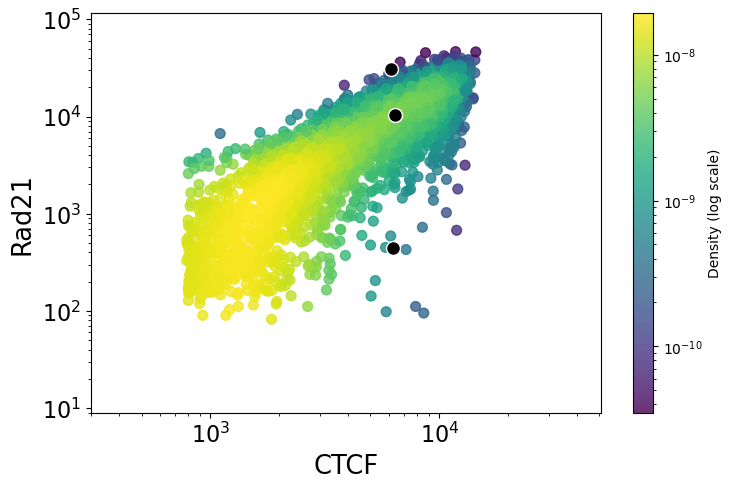

In [13]:
# Example data (replace with your real DataFrame)
file = df_merged
x = file['ctcf']
y = file['Rad21']

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)')


# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Optionally add a legend
#plt.legend(fontsize=14, loc='upper left')


# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


Max reads is 46757 and ctcf_reads is 6315.989847715737
Median reads value: 26497.5
Corresponding ctcf_reads value: 6261.111111111115


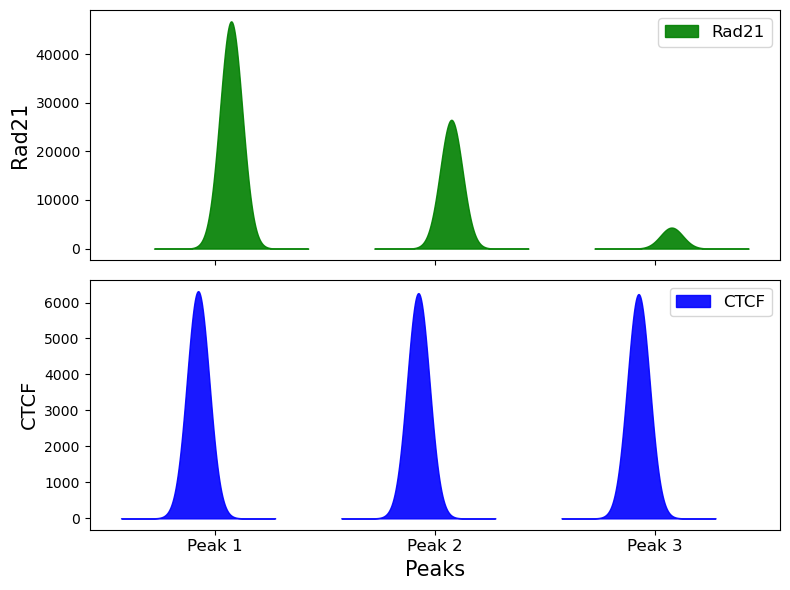

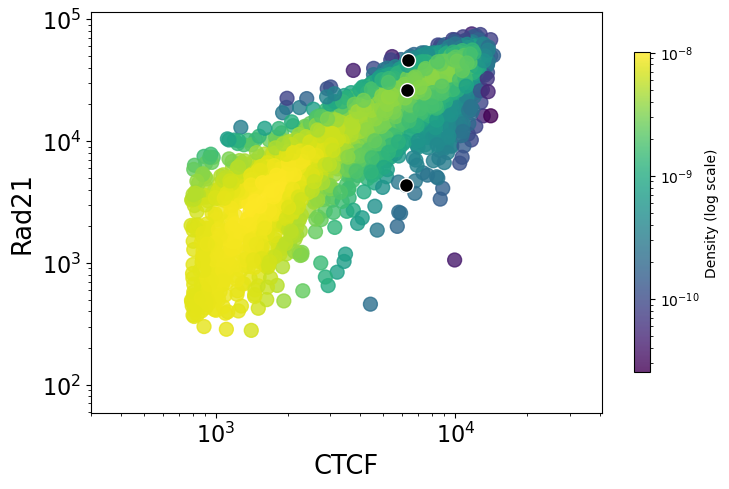

In [54]:
# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
x = file['ctcf']
y = file['Rad21']


#file = df_merged
#rounded_file = file.round()

# Add derived columns
rounded_file['reads'] = rounded_file['Rad21'] 
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

#print(subset)
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

print(f'Max reads is {max_read} and ctcf_reads is {ctcf_max}')
print(f'Median reads value: {median_read}')
print(f'Corresponding ctcf_reads value: {ctcf_for_median_read}')






# Data
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]
x = np.arange(len(ctcf_s))

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

sigma = 0.051  # Constant width
offset = 0.075

# Plot Rad21 (top)
for i, val in enumerate(rad_s):
    mu = x[i] + offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax1.fill_between(x_fine, y, 0, color='green', alpha=0.9, label='Rad21' if i == 0 else "")
ax1.set_ylabel('Rad21', fontsize=15)
ax1.legend(fontsize=12)

# Plot CTCF (bottom)
for i, val in enumerate(ctcf_s):
    mu = x[i] - offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax2.fill_between(x_fine, y, 0, color='blue', alpha=0.9, label='CTCF' if i == 0 else "")
ax2.set_ylabel('CTCF', fontsize=14)
ax2.legend(fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Peak {i+1}' for i in x], fontsize=12)
ax2.set_xlabel('Peaks', fontsize=15)

plt.tight_layout()
plt.show()





x = file['ctcf']
y = file['Rad21']
# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=100, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)


# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Optionally add a legend
#plt.legend(fontsize=14, loc='upper left')


# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 41000)
plt.ylim(59, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


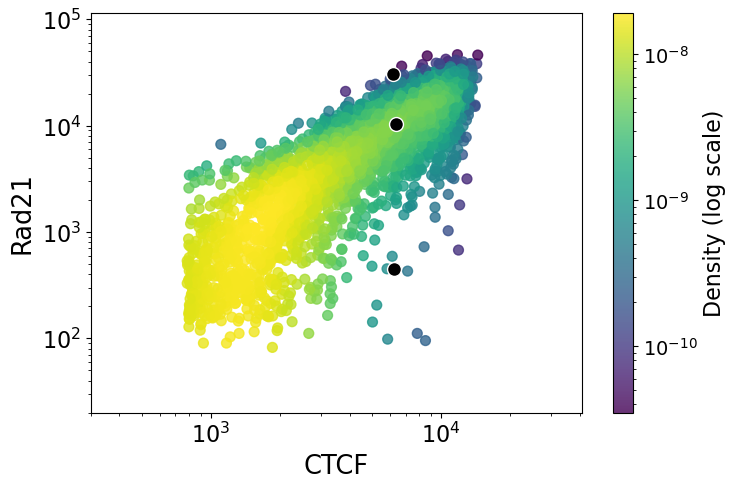

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
x = file['ctcf']
y = file['Rad21']

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21'] 
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 41000)
plt.ylim(20, 115000)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


In [77]:
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
file

,Rad21,ctcf
0,1796,1419.331395
1,22121,5565.000000
2,42821,6641.566265
3,40458,10350.000000
4,37239,7075.452017
...,...,...
3577,4708,1143.145161
3578,45390,10171.875000
3579,43834,11187.931034
3580,15180,2922.680412


In [119]:
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
file['Rad21'].sum()/16/rad21reads

0.19389351851851852

In [120]:
file = pd.read_csv('Rad21_vs_ctcf_reads_conf_newtot.csv')
file['Rad21'].sum()/16/rad21reads

0.13165886243386243

### calculations

In [18]:
genome_len =3*2725521370 # the factor of 3 is considering 3 copies of each chromosome
experimental = 0.016764/3 
experimental

0.005588

In [19]:
simlen= 37500000-30000000
simlen

7500000

In [20]:
file = (
    'simulations/sims_random_mod_run_15/folder_face_1.0_back_0.0_Clife_300_Cof_180_life_660.0_'
    'slife_660.0_birth_0.1_pause_0.9_sep_74_site_10_replica_10_vel_1_steps_20/simulation_1/LEFPositions.h5'
)
f = h5py.File(file, 'r')
lefs = h5py.File(file, 'r')['positions']
lef = np.array(lefs)
lef.shape
rad21reads = lef.shape[0]*lef.shape[1]*lef.shape[2]*5
rad21reads  
rad21persimlen = rad21reads/(10*simlen)
rad21persimlen
rad21normalizer = experimental/rad21persimlen
rad21normalizer

0.01639960086869754

In [21]:
ctcf_right = np.array(f['CTCF_positions_right']).shape
ctcf_left = np.array(f['CTCF_positions_left']).shape
ctcf_right
replication = 10
ctcf_reads =  (ctcf_right[0]*ctcf_right[1]+ctcf_left[0]*ctcf_left[1])*replication*5
ctcf_reads = (np.sum(np.array(f['CTCF_positions_right']))+np.sum(np.array(f['CTCF_positions_left'])))*replication*5
ctcf_reads
ctcfpersimlen = ctcf_reads/(10*simlen)
ctcfpersimlen
ctcfnormalizer = experimental/(ctcfpersimlen)
ctcfnormalizer

0.013301425991576715

In [22]:
rad21reads/ctcf_reads

0.8110822999946046

In [33]:
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
x = file['ctcf']#*ctcfnormalizer
y = file['Rad21']#*rad21normalizer
x.sum(), y.sum()/15 # 15 

(22576907.51939607, 2638503.0)

In [34]:
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
x = file['ctcf']*10*ctcfnormalizer*0.308
y = file['Rad21']*rad21normalizer
x.sum(), y.sum() # 15 

(1546863.2897795644, 1300172.3777777776)

In [38]:
### normalization 

In [23]:
file = pd.read_csv('Rad21_vs_ctcf_reads_bound.csv')
file['ctcf'] = file['ctcf']*ctcfnormalizer*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']*rad21normalizer
file.to_csv('Rad21_vs_ctcf_reads_boundfixed.csv')

In [24]:
file = pd.read_csv('Rad21_vs_ctcf_reads_unbound.csv')
file['ctcf'] = file['ctcf']*ctcfnormalizer*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']*rad21normalizer
file.to_csv('Rad21_vs_ctcf_reads_unboundfixed.csv')

In [4]:
def Calculate_EOC_reads(paramdict, lefs_array, lst, window_size):
    rep = paramdict['number_of_replica'] 
    mon = paramdict['monomers_per_replica']
    site = paramdict['sites_per_monomer']
    mapN = paramdict['monomers_per_replica']*paramdict['sites_per_monomer']
    lst_t = []
    for i in range(rep):
        lst_t += list(np.array(lst)+i*mon*site)
    lef_lefts = lefs_array[:,:,0].flatten()
    lef_rights = lefs_array[:,:,1].flatten()
    lef_positions = np.hstack((lef_lefts,lef_rights))
    peak_monomers = utils_s.peak_positions(lst_t, window_sizes = np.arange(-window_size, (window_size)+1))
    num_sites_t = mapN*rep
    hist,edges = np.histogram(  lef_positions  , np.arange(num_sites_t+1) )
    reads = np.sum(hist[peak_monomers])
    return reads

In [5]:
import numpy as np

def nearest_neighbor_dist(barriers):
    """Distance to the nearest neighbor (by value) for each element, returned in original order."""
    b = np.asarray(barriers)
    n = b.size
    if n < 2:
        return np.zeros_like(b, dtype=float)

    # indices that would sort the array
    order = np.argsort(b, kind='mergesort')   # stable sort helps with ties
    sorted_b = b[order]

    # distances in the sorted array
    d = np.diff(sorted_b)
    near_sorted = np.empty_like(sorted_b, dtype=float)
    near_sorted[0]  = d[0]
    near_sorted[-1] = d[-1]
    if n > 2:
        near_sorted[1:-1] = np.minimum(d[:-1], d[1:])

    # map distances back to the original order
    out = np.empty_like(near_sorted)
    out[order] = near_sorted
    return out


In [ ]:
ctcf_occup = ctcf_lifetime_list/ (ctcf_lifetime_list+ctcf_offtime_list)
traj = lefs_array.shape[0]
ctcf_reads = ctcf_occup*traj
ctcf_reads


file = open(OUTPUT_FILE_READS,'w')
file.write('Rad21,ctcf\n')
for i in range(len(ctcf_loc_list)):
    lst_e = [ctcf_loc_list[i]]
    reads = Calculate_EOC_reads(PARAMDICT, lefs_array, lst_e, WINDOW_SIZE)
    reads_per_ctcf = reads/ctcf_reads[i]
    file.write('%s,%s\n'%(reads,ctcf_reads[i]))
file.close()

In [19]:
import numpy as np

def nearest_neighbor_dist(barriers):
    """Distance to the nearest neighbor (by value) for each element, returned in original order."""
    b = np.asarray(barriers)
    n = b.size
    if n < 2:
        return np.zeros_like(b, dtype=float)

    # indices that would sort the array
    order = np.argsort(b, kind='mergesort')   # stable sort helps with ties
    sorted_b = b[order]

    # distances in the sorted array
    d = np.diff(sorted_b)
    near_sorted = np.empty_like(sorted_b, dtype=float)
    near_sorted[0]  = d[0]
    near_sorted[-1] = d[-1]
    if n > 2:
        mask = d[:-1] <= d[1:]                                   # True -> pick left
        near_sorted[1:-1] = np.where(mask, d[:-1], d[1:])

    # map distances back to the original order
    out = np.empty_like(near_sorted)
    out[order] = near_sorted
    return out


In [17]:
import OccupancyInputCTCF.utils.convert as convert

In [18]:
REGION = 'chr1:30000000-37500000'
PARAMDICT_PATH = 'data/paramdict.json'
import json
with open(PARAMDICT_PATH, 'r') as json_file:
    PARAMDICT = json.load(json_file)
PARAMDICT['monomers_per_replica'] = convert.get_lattice_size(REGION, lattice_site=250)//10
PARAMDICT

{'CTCF_facestall': [1.0],
 'CTCF_backstall': [0.0],
 'CTCF_lifetime': [300],
 'CTCF_offtime': [180],
 'LEF_lifetime': [660],
 'LEF_stalled_lifetime': [660],
 'LEF_birth': [0.1],
 'LEF_pause': [0.9],
 'LEF_separation': 75,
 'sites_per_monomer': 10,
 'number_of_replica': 10,
 'velocity_multiplier': 1,
 'steps': 20,
 'monomers_per_replica': 3000}

In [20]:
a = [5, 10, 14, 4, 8]
nearest_neighbor_dist(a)

array([1., 2., 4., 1., 2.])

In [10]:
### enrichment vs distance


In [10]:
paramdict = PARAMDICT
rep = paramdict['number_of_replica'] 
mon = paramdict['monomers_per_replica']
site = paramdict['sites_per_monomer']
mapN = paramdict['monomers_per_replica']*paramdict['sites_per_monomer']

In [15]:
name = 'folder_face_1.0_back_0.0_Clife_300_Cof_180_life_660.0_slife_660.0_birth_0.1_pause_0.9_sep_74_site_10_replica_10_vel_1_steps_20'
directory = 'simulations/'
for simid in range(1):
    for part in range(1,2):
        filepath = directory + 'sims_random_mod_run_%s/'%simid +name +'/simulation_%s/'%part+'LEFPositions.h5'
        with h5py.File(filepath, 'r') as file:
            lefs_array = np.array(file['positions'])
            ctcfrightlist = np.array(file['CTCF_sites_right'])
            ctcfleftlist = np.array(file['CTCF_sites_left'])
            ctcfrightsites = np.array(file['CTCF_positions_right'])
            ctcfleftsites = np.array(file['CTCF_positions_left'])
            occuprightsites = np.sum(ctcfrightsites, axis=0)#/ctcfrightsites.shape[0]
            occupleftsites = np.sum(ctcfleftsites, axis=0)

In [12]:
np.max(lefs_array)

299998

In [13]:
len(lefs_array)

3150

In [16]:
np.max(occuprightsites)

3150.0

In [57]:
occuprightsites.shape

(117, 1)

In [58]:
ctcfrightsites.shape

(3150, 117, 1)

In [45]:
name = 'folder_face_1.0_back_0.0_Clife_300_Cof_180_life_660.0_slife_660.0_birth_0.1_pause_0.9_sep_74_site_10_replica_10_vel_1_steps_20'
directory = 'simulations/'
filer = open('readsvsnear.csv','w')
filer.write('Rad21,ctcf,position,distnear\n')
for simid in range(5):
    for part in range(1,6):
        filepath = directory + 'sims_random_mod_run_%s/'%simid +name +'/simulation_%s/'%part+'LEFPositions.h5'
        with h5py.File(filepath, 'r') as file:
            lefs_array = np.array(file['positions'])
            ctcfrightlist = np.array(file['CTCF_sites_right'])
            ctcfleftlist = np.array(file['CTCF_sites_left'])
            ctcfrightsites = np.array(file['CTCF_positions_right'])
            ctcfleftsites = np.array(file['CTCF_positions_left'])
            occuprightsites = np.sum(ctcfrightsites, axis=0)#/ctcfrightsites.shape[0]
            occupleftsites = np.sum(ctcfleftsites, axis=0)#/ctcfleftsites.shape[0]
            ctcf_reads = np.array(list(occuprightsites))#+list(occupleftsites))
            lst = np.array(list(ctcfrightlist))#+list(ctcfleftlist))
            nearst = nearest_neighbor_dist(lst) 
            for i in range(len(lst)):
            #for i in range(10):
                lst_e = [lst[i]]
                #print(lst[i])
                reads = Calculate_EOC_reads(PARAMDICT, lefs_array, lst_e, 0)
                distnear = nearst[i]
                #print(distnear)
                #print(ctcf_reads[i])
                filer.write('%s,%s,%s,%s\n'%(reads,ctcf_reads[i][0],lst[i],distnear))
filer.close()                
            

In [46]:
rfile = pd.read_csv('readsvsnear.csv')
rfile

,Rad21,ctcf,position,distnear
0,119,460.0,15133,93.0
1,3794,3150.0,16884,112.0
2,3950,0.0,23647,86.0
3,17,322.0,18216,41.0
4,148,10.0,20081,84.0
...,...,...,...,...
2870,2988,3150.0,26114,234.0
2871,28,844.0,13324,278.0
2872,377,0.0,27899,109.0
2873,828,3150.0,24118,569.0


In [38]:
np.max(rfile['Rad21']/(10*rfile['ctcf']))

inf

In [31]:
np.min(rfile['ctcf'])

0.0

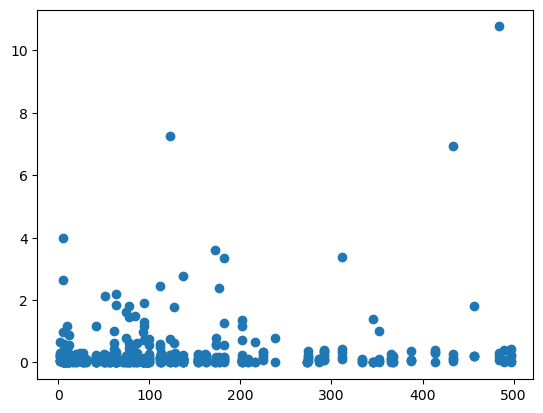

In [39]:
plt.scatter(rfile['distnear'],rfile['Rad21']/(10*rfile['ctcf']))

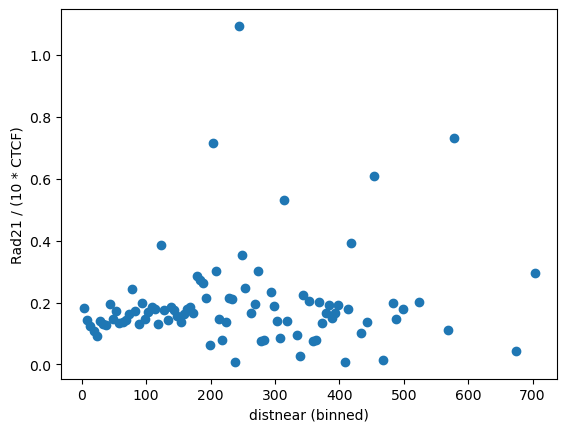

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rfile = pd.read_csv('readsvsnear.csv')
rfile = rfile[rfile['ctcf']>100]
#rfile['distnear']*=0.25
df = rfile.copy()
df['ratio'] = df['Rad21'] / (10 * df['ctcf'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['ratio', 'distnear'])

# choose a bin width (change as you like)
bin_width = 5
bins = np.arange(df['distnear'].min(), df['distnear'].max() + bin_width, bin_width)

# bin and aggregate
df['bin'] = pd.cut(df['distnear'], bins, include_lowest=True)
g = df.groupby('bin', observed=True)['ratio'].mean()

# x = bin centers
centers = g.index.map(lambda iv: (iv.left + iv.right) / 2.0)

plt.scatter(centers, g.values)
plt.xlabel('distnear (binned)')
plt.ylabel('Rad21 / (10 * CTCF)')
plt.show()


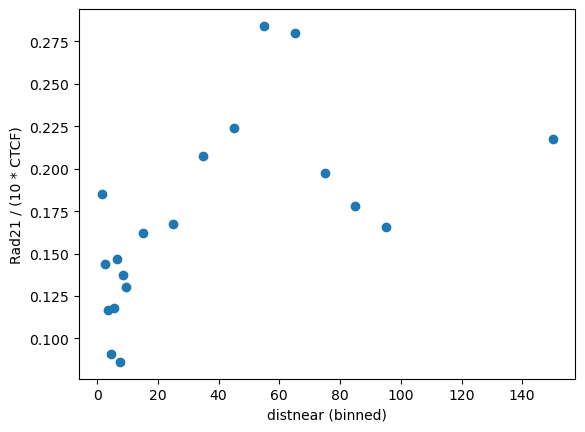

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rfile = pd.read_csv('readsvsnear.csv')
rfile = rfile[rfile['ctcf']>100]

rfile['distnear'] *= 0.25

df = rfile.copy()
df['ratio'] = df['Rad21'] / (10 * df['ctcf'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['ratio', 'distnear'])

# --- custom edges: 1..10 by 1, 10..100 by 10, 100..1000 by 100 ---
edges = np.unique(np.r_[np.arange(1, 11, 1),
                        np.arange(10, 101, 10),
                        np.arange(100, 1001, 100)]).astype(float)

# keep only values covered by the bins (or remove this mask if you want out-of-range bins)
df = df[df['distnear'].between(edges[0], edges[-1])]

# bin and aggregate
df['bin'] = pd.cut(df['distnear'], bins=edges, include_lowest=True, right=True)
g = df.groupby('bin', observed=True)['ratio'].mean()

# bin centers for plotting
centers = g.index.map(lambda iv: (iv.left + iv.right) / 2.0)

plt.scatter(centers, g.values)
plt.xlabel('distnear (binned)')
plt.ylabel('Rad21 / (10 * CTCF)')
# optional: log x-axis to reflect decades
# plt.xscale('log')
plt.show()


In [12]:
# Define the file pattern
file_pattern = "data/Rad21_vs_ctcf_reads_random_mod_a_w_chr1*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)
print(len(csv_files))
# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_bound.csv', index=False)

20


In [14]:
# Define the file pattern
file_pattern = "data/Rad21_vs_ctcf_reads_random_mod_a_w_conf_chr1*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)
print(len(csv_files))
# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_unbound.csv', index=False)

20


In [15]:
df = pd.read_csv('Rad21_vs_ctcf_reads_unbound.csv')
df

,Rad21,ctcf,ctcfloc,nearest
0,7573,2850.188206,4548,130.0
1,8993,9818.464730,9149,298.0
2,21206,26467.477204,3074,85.0
3,3812,6658.279221,27760,57.0
4,32222,19022.794118,10468,13.0
...,...,...,...,...
4473,10945,12134.615385,25641,53.0
4474,19366,19415.384615,4123,11.0
4475,20173,20392.362679,11255,43.0
4476,3560,1629.342723,5533,147.0


In [19]:
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnearnew.csv')
file['ctcf'] = file['ctcf']*ctcfnormalizer*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']*rad21normalizer
file.to_csv('Rad21_vs_ctcf_reads_newtot_withnearnew_fixed.csv')

In [10]:
df['nearest'].max()

590.0

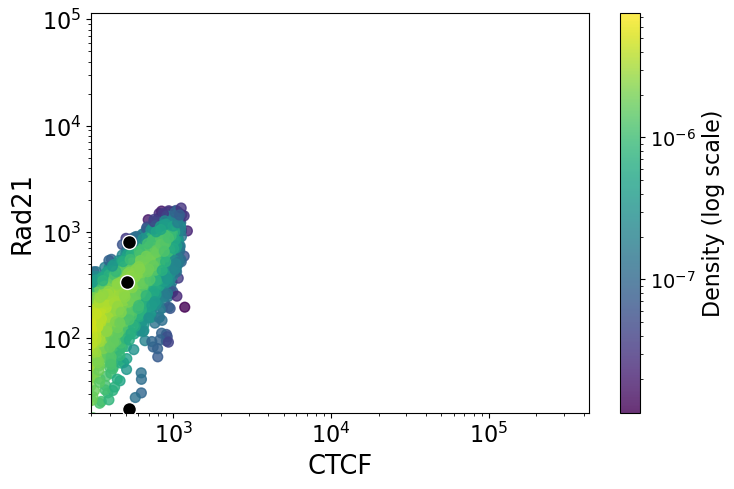

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnearnew_fixed.csv')
x = file['ctcf']
y = file['Rad21']

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21'] 
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 431000)
plt.ylim(20, 115000)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


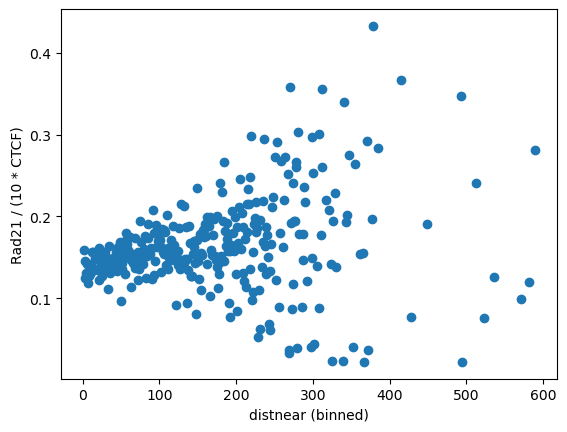

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnearnew.csv')
rfile = rfile[rfile['ctcf']>10]
#rfile['distnear']*=0.25
df = rfile.copy()
df['ratio'] = df['Rad21'] / ( 10*df['ctcf'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['ratio', 'nearest'])

# choose a bin width (change as you like)
bin_width = 1
bins = np.arange(df['nearest'].min(), df['nearest'].max() + bin_width, bin_width)

# bin and aggregate
df['bin'] = pd.cut(df['nearest'], bins, include_lowest=True)
g = df.groupby('bin', observed=True)['ratio'].mean()

# x = bin centers
centers = g.index.map(lambda iv: (iv.left + iv.right) / 2.0)

plt.scatter(centers, g.values)
plt.xlabel('distnear (binned)')
plt.ylabel('Rad21 / (10 * CTCF)')
plt.show()


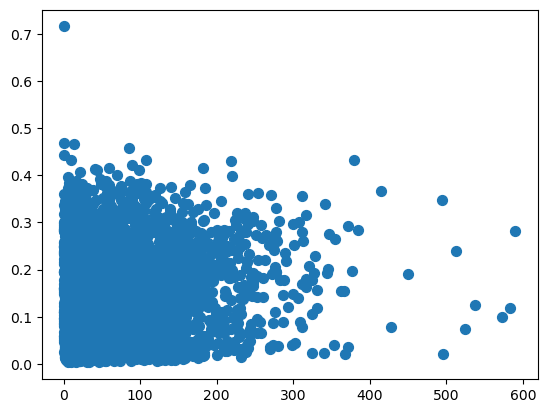

In [14]:
rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnearnew.csv')
plt.scatter(rfile['nearest'],rfile['Rad21']/(10*rfile['ctcf']), s=50)

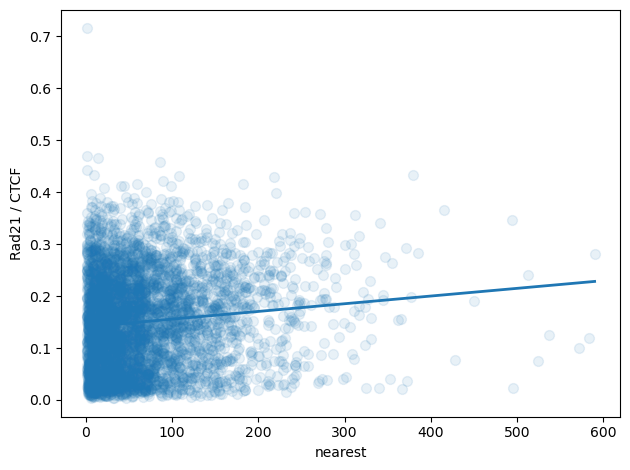

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load
rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnearnew.csv')

# x and y
x = rfile['nearest'].to_numpy()
y = (rfile['Rad21'] / (10 * rfile['ctcf'])).to_numpy()

# keep only finite pairs
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

# ordinary least squares: y = m*x + b
m_hat, b_hat = np.polyfit(x, y, 1)

# R^2
y_pred = m_hat * x + b_hat
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

# line for plotting
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m_hat * x_line + b_hat

# plot
plt.scatter(x, y, s=50, alpha=0.1)
plt.plot(x_line, y_line, linewidth=2)

plt.xlabel('nearest')
plt.ylabel('Rad21 / CTCF')
#plt.title(f'Linear fit: y = {m_hat:.3g}·x + {b_hat:.3g}   (R² = {r2:.3f})')
plt.tight_layout()
plt.show()


In [101]:
pip install brokenaxes


INFO: pip is looking at multiple versions of brokenaxes to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.


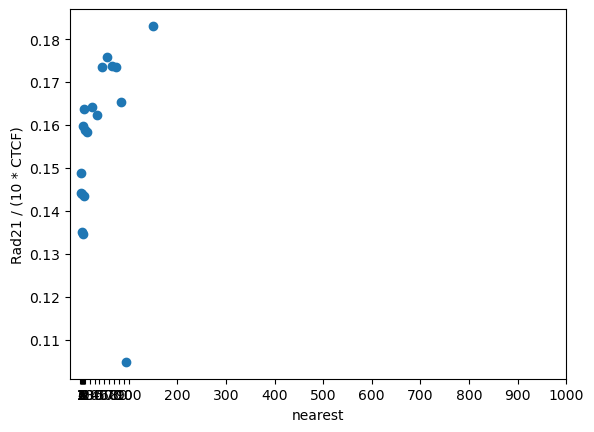

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnear.csv')
rfile = rfile[rfile['ctcf']>100]

rfile['nearest'] *= 0.25

df = rfile.copy()
df['ratio'] = df['Rad21'] / (10 * df['ctcf'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['ratio', 'nearest'])

# --- custom edges: 1..10 by 1, 10..100 by 10, 100..1000 by 100 ---
edges = np.unique(np.r_[np.arange(1, 11, 1),
                        np.arange(10, 101, 10),
                        np.arange(100, 1001, 100)]).astype(float)

# keep only values covered by the bins (or remove this mask if you want out-of-range bins)
df = df[df['nearest'].between(edges[0], edges[-1])]

# bin and aggregate
df['bin'] = pd.cut(df['nearest'], bins=edges, include_lowest=True, right=True)
g = df.groupby('bin', observed=True)['ratio'].mean()

# bin centers for plotting
centers = g.index.map(lambda iv: (iv.left + iv.right) / 2.0)

plt.scatter(centers, g.values)
plt.xlabel('distnear (binned)')
plt.ylabel('Rad21 / (10 * CTCF)')
ticks = np.r_[np.arange(1, 11, 1),     # 1..10 by 1
              np.arange(20, 101, 10),  # 20..100 by 10 (10 already included)
              np.arange(200, 1001, 100)]  # 200..1000 by 100 (100 already included)
plt.xlim(-20, 1000)
plt.xticks(ticks)
plt.xlabel('nearest')
plt.ylabel('Rad21 / (10 * CTCF)')
plt.show()
# optional: log x-axis to reflect decades
# plt.xscale('log')
plt.show()


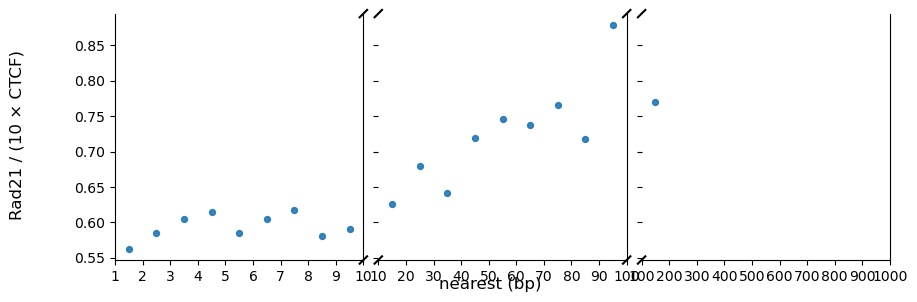

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- load & prep ---
#rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnearnew_fixed.csv')
rfile = pd.read_csv('Rad21_vs_ctcf_reads_boundfixed.csv')
rfile = rfile[rfile['ctcf'] > 100]
rfile['nearest'] = rfile['nearest'] * 0.25

df = rfile.copy()
df['ratio'] = df['Rad21'] / ( df['ctcf'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['nearest', 'ratio'])

# --- custom bin edges: 1..10 by 1, 10..100 by 10, 100..1000 by 100 ---
edges = np.unique(np.r_[np.arange(1, 11, 1),
                        np.arange(10, 101, 10),
                        np.arange(100, 1001, 100)]).astype(float)

# keep only values in range
df = df[df['nearest'].between(edges[0], edges[-1])]

# bin and aggregate (1 point per bin)
df['bin'] = pd.cut(df['nearest'], bins=edges, include_lowest=True, right=True)
g = df.groupby('bin', observed=True)['ratio'].mean()

# bin centers for plotting
centers = np.array([(iv.left + iv.right) / 2.0 for iv in g.index.to_numpy()])
values  = g.to_numpy()

# --- plot with equal-width panels for each range ---
x = centers
y = values

m1 = (x >= 1)   & (x <= 10)
m2 = (x > 10)   & (x <= 100)
m3 = (x > 100)  & (x <= 1000)

fig = plt.figure(figsize=(10, 3.2))
# three panels, equal widths
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.06)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)

for ax, mask, xlim, ticks in [
    (ax1, m1, (1, 10),    np.arange(1, 11, 1)),
    (ax2, m2, (10, 100),  np.arange(10, 101, 10)),
    (ax3, m3, (100, 1000),np.arange(100, 1001, 100)),
]:
    ax.scatter(x[mask], y[mask], s=18, alpha=0.9)
    ax.set_xlim(*xlim)
    ax.set_xticks(ticks)
    ax.spines['top'].set_visible(False)

# clean shared y-axis
ax2.tick_params(labelleft=False)
ax3.tick_params(labelleft=False)
ax2.spines['left'].set_visible(False)
ax3.spines['left'].set_visible(False)

# draw small slashes to indicate breaks
d = .015
kw = dict(color='k', clip_on=False)
# right of ax1
ax1.plot((1-d, 1+d), (-d, +d), transform=ax1.transAxes, **kw)
ax1.plot((1-d, 1+d), (1-d, 1+d), transform=ax1.transAxes, **kw)
# both sides of ax2
ax2.plot((-d, +d), (-d, +d),    transform=ax2.transAxes, **kw)
ax2.plot((-d, +d), (1-d, 1+d),  transform=ax2.transAxes, **kw)
ax2.plot((1-d, 1+d), (-d, +d),  transform=ax2.transAxes, **kw)
ax2.plot((1-d, 1+d), (1-d, 1+d),transform=ax2.transAxes, **kw)
# left of ax3
ax3.plot((-d, +d), (-d, +d),    transform=ax3.transAxes, **kw)
ax3.plot((-d, +d), (1-d, 1+d),  transform=ax3.transAxes, **kw)

fig.supxlabel('nearest (bp)')
fig.supylabel('Rad21 / (10 × CTCF)')

plt.tight_layout()
plt.show()


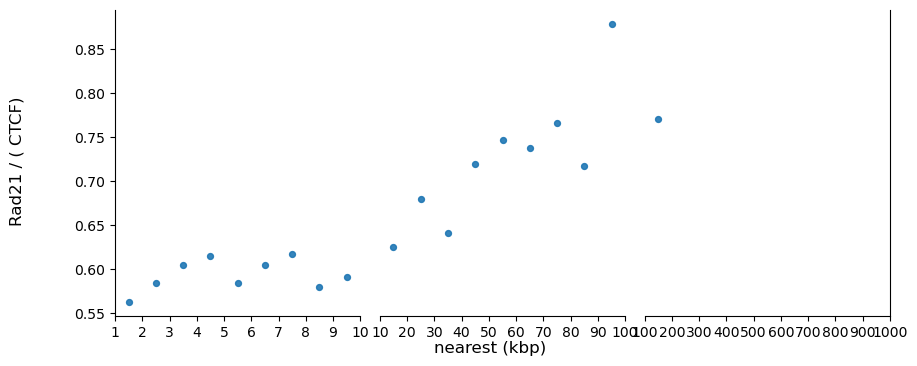

In [31]:
# --- plot with equal-width panels, no vertical lines between them ---
x = centers
y = values

m1 = (x >= 1)   & (x <= 10)
m2 = (x > 10)   & (x <= 100)
m3 = (x > 100)  & (x <= 1000)

fig = plt.figure(figsize=(10, 3.98))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.08)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)

for ax, mask, xlim, ticks in [
    (ax1, m1, (1, 10),     np.arange(1, 11, 1)),
    (ax2, m2, (10, 100),   np.arange(10, 101, 10)),
    (ax3, m3, (100, 1000), np.arange(100, 1001, 100)),
]:
    ax.scatter(x[mask], y[mask], s=18, alpha=0.9)
    ax.set_xlim(*xlim)
    ax.set_xticks(ticks)
    ax.spines['top'].set_visible(False)

# remove vertical spines so the “breaks” are just empty space
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax1.tick_params(axis='y', which='both', right=False)
ax2.tick_params(axis='y', which='both', left=False, right=False)
ax3.tick_params(axis='y', which='both', left=False)

# no diagonal “break” marks
# (intentionally not drawing any)

# tidy shared y
ax2.tick_params(labelleft=False)
ax3.tick_params(labelleft=False)

fig.supxlabel('nearest (kbp)')
fig.supylabel('Rad21 / ( CTCF)')
#plt.tight_layout()
plt.show()


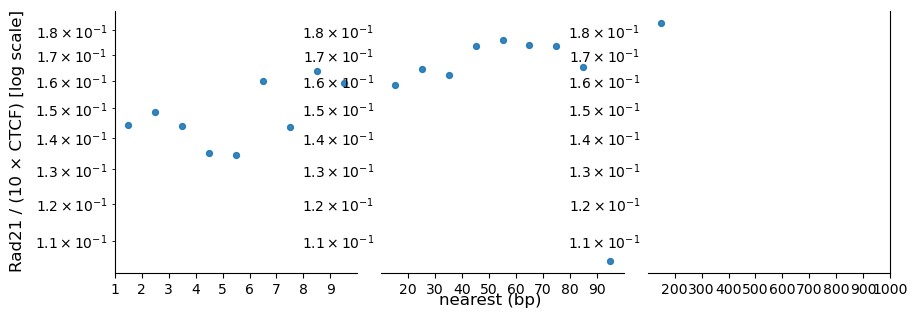

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- load & prep ---
rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot_withnear.csv')
rfile = rfile[rfile['ctcf'] > 100]
rfile['nearest'] = rfile['nearest'] * 0.25

df = rfile.copy()
df['ratio'] = df['Rad21'] / (10 * df['ctcf'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['nearest', 'ratio'])

# --- custom bin edges: 1..10 by 1, 10..100 by 10, 100..1000 by 100 ---
edges = np.unique(np.r_[np.arange(1, 11, 1),
                        np.arange(10, 101, 10),
                        np.arange(100, 1001, 100)]).astype(float)

# keep only values in range
df = df[df['nearest'].between(edges[0], edges[-1])]

# bin and aggregate (1 point per bin)
df['bin'] = pd.cut(df['nearest'], bins=edges, include_lowest=True, right=True)
g = df.groupby('bin', observed=True)['ratio'].mean()

# bin centers & values; drop empty bins and nonpositive (for log scale)
centers = np.array([(iv.left + iv.right) / 2.0 for iv in g.index.to_numpy()])
values  = g.to_numpy()
m_valid = np.isfinite(values) & (values > 0)
x = centers[m_valid]
y = values[m_valid]

# masks per range
m1 = (x >= 1)   & (x <= 10)
m2 = (x > 10)   & (x <= 100)
m3 = (x > 100)  & (x <= 1000)

# --- plot with equal-width panels, clean gaps, log Y ---
fig = plt.figure(figsize=(10, 3.4))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.10)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)

for ax, mask, xlim, ticks in [
    # NOTE: drop edge ticks at the breaks (no tick at 10 or 100)
    (ax1, m1, (1, 10),     np.arange(1, 10, 1)),        # 1..9
    (ax2, m2, (10, 100),   np.arange(20, 100, 10)),     # 20..90
    (ax3, m3, (100, 1000), np.arange(200, 1001, 100)),  # 200..1000
]:
    ax.scatter(x[mask], y[mask], s=18, alpha=0.9)
    ax.set_xlim(*xlim)
    ax.set_xticks(ticks)
    ax.set_yscale('log')
    ax.spines['top'].set_visible(False)

# remove interior spines AND their ticks so gaps are pure white space
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax1.tick_params(axis='y', which='both', right=False)
ax2.tick_params(axis='y', which='both', left=False, right=False)
ax3.tick_params(axis='y', which='both', left=False)

# tidy shared y labels (only left panel shows them)
ax2.tick_params(labelleft=False)
ax3.tick_params(labelleft=False)

fig.supxlabel('nearest (bp)')
fig.supylabel('Rad21 / (10 × CTCF) [log scale]')
plt.tight_layout()
plt.show()


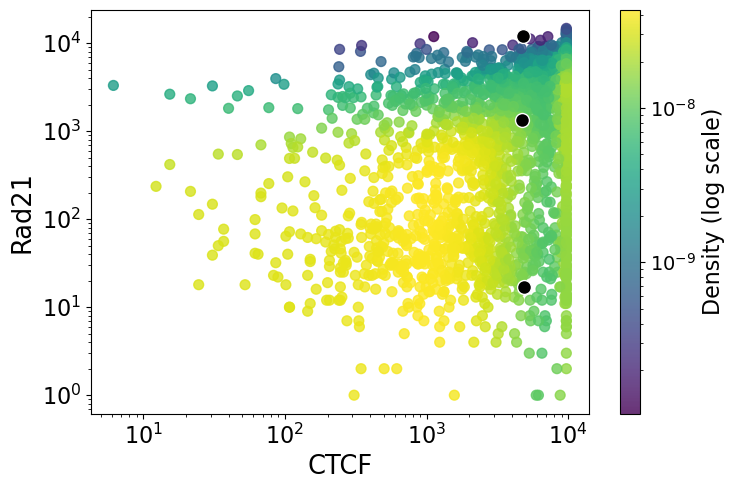

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('readsvsnear.csv')
file['ctcf'] = file['ctcf']*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']
x = file['ctcf']
y= file['Rad21']

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21']
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
#plt.xlim(28, 3150)
#plt.ylim(0.92, 8100)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


In [34]:
rfile = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
rfile

,Rad21,ctcf
0,5133,7614.238411
1,1375,9419.117647
2,11794,6176.470588
3,27368,12989.690722
4,27442,11045.454545
...,...,...
3605,10724,8195.121951
3606,9954,5660.526316
3607,20755,8665.048544
3608,11467,8969.730942


In [35]:
np.max(rfile['Rad21']/rfile['ctcf'])

6.0489795918367335

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# safe ratio (NaN where ctcf == 0)
ratio = rfile['Rad21'].div(rfile['ctcf']).replace([np.inf, -np.inf], np.nan)

# x-axis: use the dataframe index or a simple 0..n-1 range
x = rfile.index  # or: np.arange(len(rfile))

# plot only finite values
m = np.isfinite(ratio.to_numpy())
plt.scatter(x[m], ratio[m], s=12, alpha=0.8)
plt.xlabel('row index')
plt.ylabel('Rad21 / CTCF')
plt.title('Rad21 to CTCF ratio')
plt.show()


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [69]:
rfile = pd.read_csv('readsvsnear.csv')
rfile


,Rad21,ctcf,position,distnear
0,119,460.0,15133,93.0
1,3794,3150.0,16884,112.0
2,3950,0.0,23647,86.0
3,17,322.0,18216,41.0
4,148,10.0,20081,84.0
...,...,...,...,...
105,9,399.0,24810,334.0
106,13,3150.0,10290,162.0
107,4707,0.0,28811,484.0
108,92,0.0,26093,57.0


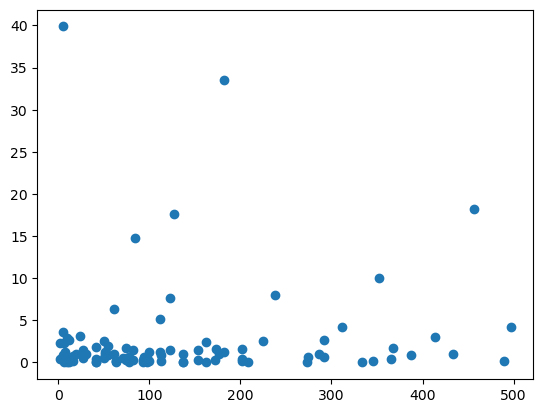

In [32]:
plt.scatter(rfile['distnear'],rfile['Rad21']/rfile['ctcf'])

In [22]:
a = np.array([1, 5, 8])
b = np.array([4, 6, 9])
np.concatenate([a,b])

array([1, 5, 8, 4, 6, 9])

In [39]:
import numpy as np

def nearest_neighbor_dist(barriers):
    """Distance to the nearest neighbor (by value) for each element, returned in original order."""
    b = np.asarray(barriers)
    n = b.size
    if n < 2:
        return np.zeros_like(b, dtype=float)

    # indices that would sort the array
    order = np.argsort(b, kind='mergesort')   # stable sort helps with ties
    sorted_b = b[order]

    # distances in the sorted array
    d = np.diff(sorted_b)
    near_sorted = np.empty_like(sorted_b, dtype=float)
    near_sorted[0]  = d[0]
    near_sorted[-1] = d[-1]
    if n > 2:
        near_sorted[1:-1] = np.minimum(d[:-1], d[1:])

    # map distances back to the original order
    out = np.empty_like(near_sorted)
    out[order] = near_sorted
    return out


In [68]:
lst[10], dists[10]

(1544, 128.0)

In [23]:
ctcfrightsites.shape

(3150, 110, 1)

In [54]:
occuprightsites = np.sum(ctcfrightsites, axis=0)/ctcfrightsites.shape[0]
occupleftsites = np.sum(ctcfleftsites, axis=0)/ctcfleftsites.shape[0]

In [24]:
ctcfrightlist.shape

(110,)

In [16]:
with h5py.File(filepath, 'r') as file:
    print(list(file.keys()))

['CTCF_positions_left', 'CTCF_positions_right', 'CTCF_sites_left', 'CTCF_sites_right', 'positions']


In [60]:
occuplist = np.concatenate([occuprightsites,occupleftsites])

In [59]:
##### Visualization

In [35]:
paramdict_CTCF = {
    'CTCF_facestall': [1, 1],
    'CTCF_backstall': [0., 0.],
    'CTCF_lifetime': [1, 1],
    'CTCF_offtime': [0.1, 0.1],
    'LEF_lifetime': [500, 500],
    'LEF_stalled_lifetime': [500, 500],
    'LEF_birth': [0.1, 0.1],
    'LEF_pause': [0.9, 0.9],
    'LEF_ipause': [0.9, 0.9],
    'LEF_separation': 300,
    'sites_per_monomer': 10,
    'monomers_per_replica': 1000,
    'number_of_replica': 1,
    'steps': 200,
    'velocity_multiplier': 1
}

In [36]:
monomers_per_replica = paramdict_CTCF['monomers_per_replica'] 
sites_per_monomer = paramdict_CTCF['sites_per_monomer']
sites_per_replica = monomers_per_replica*sites_per_monomer
monomer_types = np.zeros(monomers_per_replica, dtype=int)
site_types = np.repeat(monomer_types, sites_per_monomer)
#print(len(site_types))

# Let's make some strong and weak CTCF regions
typedict = {'strong_CTCF':1, 'weak_CTCF':0}
site_types[15000:15300] = typedict['strong_CTCF']
site_types[:15000] = site_types[15300:] = typedict['weak_CTCF']


# LEF/CTCF properties in type A monomers may be obtained from the paramdict as follows
LEF_lifetime = paramdict_CTCF['LEF_lifetime']
CTCF_facestall = paramdict_CTCF['CTCF_facestall']
CTCF_offtime = paramdict_CTCF['CTCF_offtime']
#print(CTCF_offtime[typedict['strong_CTCF']], CTCF_offtime[typedict['weak_CTCF']])

# Create some CTCF boundary sites
ctcfrightlist = [314, 579, 1195, 3717, 3772, 3921, 4451, 5193, 5723, 6302, 6574, 6779, 7000, 9232, 9310, 9861]
ctcfleftlist = [495, 865, 1404, 2164, 3143, 3615, 3971, 4069, 4480, 4938, 5300, 5587, 6401, 7725, 8764, 9619]
CTCF_right_positions = np.array(ctcfrightlist)
CTCF_left_positions = np.array(ctcfleftlist)

In [37]:
monomers_per_replica = paramdict_CTCF['monomers_per_replica'] 
sites_per_monomer = paramdict_CTCF['sites_per_monomer']
sites_per_replica = monomers_per_replica*sites_per_monomer
monomer_types = np.zeros(monomers_per_replica, dtype=int)
site_types = np.repeat(monomer_types, sites_per_monomer)
#print(len(site_types))

# Let's make some strong and weak CTCF regions
typedict = {'strong_CTCF':1, 'weak_CTCF':0}
site_types[15000:15300] = typedict['strong_CTCF']
site_types[:15000] = site_types[15300:] = typedict['weak_CTCF']


# LEF/CTCF properties in type A monomers may be obtained from the paramdict as follows
LEF_lifetime = paramdict_CTCF['LEF_lifetime']
CTCF_facestall = paramdict_CTCF['CTCF_facestall']
CTCF_offtime = paramdict_CTCF['CTCF_offtime']
#print(CTCF_offtime[typedict['strong_CTCF']], CTCF_offtime[typedict['weak_CTCF']])

# Create some CTCF boundary sites
ctcfrightlist = [314, 579, 1195, 3717, 3772, 3921, 4451, 5193, 5723, 6302, 6574, 6779, 7000, 9232, 9310, 9861]
ctcfleftlist = [495, 865, 1404, 2164, 3143, 3615, 3971, 4069, 4480, 4938, 5300, 5587, 6401, 7725, 8764, 9619]
CTCF_right_positions = np.array(ctcfrightlist)
CTCF_left_positions = np.array(ctcfleftlist)

In [38]:
from Target_cohesin_loading.lattice_translocators import LEFTranslocatorDynamicBoundary
from Target_cohesin_loading.funcs import make_translocator

In [39]:
translocator = make_translocator(LEFTranslocatorDynamicBoundary, 
                                                 site_types,
                                                 CTCF_left_positions,
                                                 CTCF_right_positions, 
                                                 **paramdict_CTCF)

In [40]:
ctcfrights = np.array(translocator.stallProbRight)
ctcflefts = np.array(translocator.stallProbLeft)
print(len(ctcfrights))
ctcfrights[ctcfrightlist]

10000


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [41]:
tau_list = [  11.429, 34.286,  114.286, 500.0, 1142.857]
occup_list = [0.7]
taup_list = []
def taup_cal(tau,occup):
    taup = (tau/occup) - tau
    return taup
for tau_val in tau_list:
    for occup_val in occup_list:
        taup_val = taup_cal(tau_val, occup_val)
        taup_list.append(np.round(taup_val, 3))
print(taup_list)

[4.898, 14.694, 48.98, 214.286, 489.796]


In [42]:
ctcfrightlist = [314, 579, 1195, 3717, 3772, 3921, 4451, 5193, 5723, 6302, 6574, 6779, 7000, 9232, 9310, 9861]
#ctcfleftlist = [495, 865, 1404, 2164, 3143, 3615, 3971, 4069, 4480, 4938, 5300, 5587, 6401, 7725, 8764, 9619]
ctcfleftlist = [495, 865, 1404, 2164, 3143, 3615, 3971, 4069, 4480, 4938, 5300, 5587, 6401, 7725, 8764, 9619]
CTCF_right_positions = np.array(ctcfrightlist)
CTCF_left_positions = np.array(ctcfleftlist)
convertor =60*21.875/500
CTCF_right_positions

array([ 314,  579, 1195, 3717, 3772, 3921, 4451, 5193, 5723, 6302, 6574,
       6779, 7000, 9232, 9310, 9861])

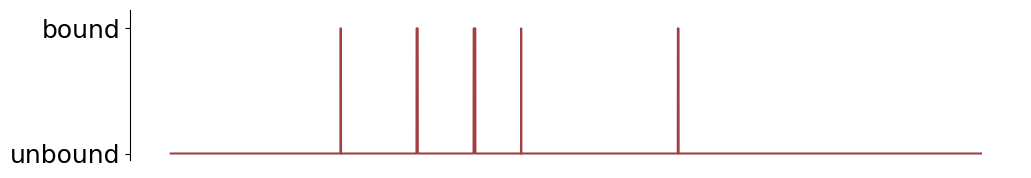

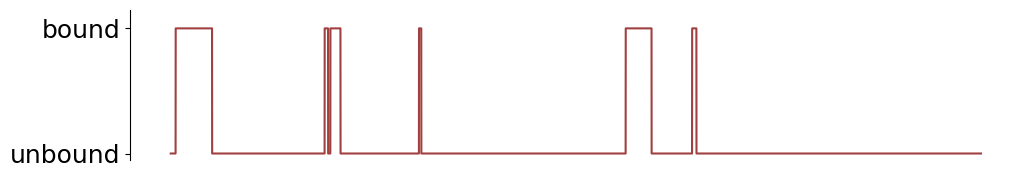

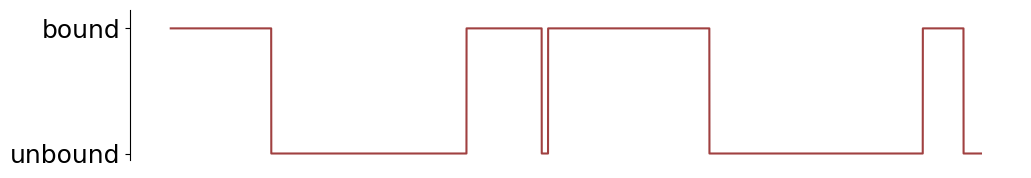

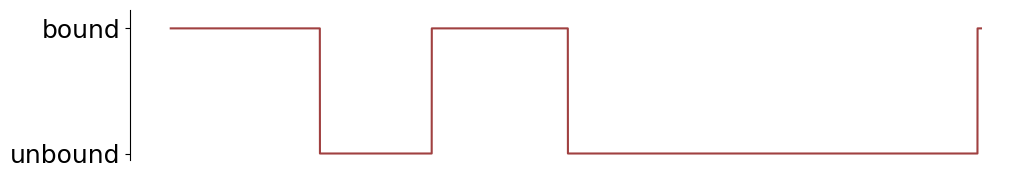

In [51]:
traj = 50000

velocity_range=[1]
lifetime_range = [500]
ctcf_life_range = [  5, 50, 500, 1000]

c=1

import matplotlib as mpl
for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for ctcf_life in ctcf_life_range:
    
            paramdict_CTCF['LEF_lifetime']=[lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime']= [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime']=[ctcf_life, ctcf_life]
            paramdict_CTCF['CTCF_offtime']=[1000, 1000]
            
            ctcfrightarys = []
            ctcfleftarys = []
            translocator = make_translocator(LEFTranslocatorDynamicBoundary, 
                                                 site_types,
                                                 CTCF_left_positions,
                                                 CTCF_right_positions, 
                                                 **paramdict_CTCF)
            site = []
            for _ in range(traj+1):
                #print(_)
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                ctcflefts = np.array(translocator.stallProbLeft)
                status = int(ctcfrights[314])
                site.append(status)
                ctcfrightstrue = np.where(ctcfrights)[0]
                #print(ctcfrightstrue)
                ctcfleftstrue = np.where(ctcflefts)[0]
                ctcfrightarys.append(ctcfrightstrue)
                ctcfleftarys.append(ctcfleftstrue)
            ctcfrightary = flattened_array = np.concatenate([arr.flatten() for arr in ctcfrightarys if arr.size > 0])
            ctcfleftary = flattened_array = np.concatenate([arr.flatten() for arr in ctcfleftarys if arr.size > 0])
            ctcfs = list(ctcfrightary)#+list(ctcfleftary)
            a, b = np.histogram(ctcfs, np.arange(0,sites_per_replica,1))
            plt.figure(figsize = (11.5,1.95))
            plt.ylim(-0.05,1.15)
            plt.plot(site, linewidth = 1.5, color = 'maroon', alpha=0.75)
            plt.yticks([0, 1], ['unbound', 'bound'], fontsize = 18)  # Replace 0 and 1 with custom labels
            plt.xticks([])
            mpl.rcParams['axes.spines.right'] = False
            mpl.rcParams['axes.spines.top'] = False
            mpl.rcParams['axes.spines.bottom'] = False
            plt.savefig('site_status_for_boundtime_%s.pdf'%ctcf_life, transparent = True)
            
            plt.show()

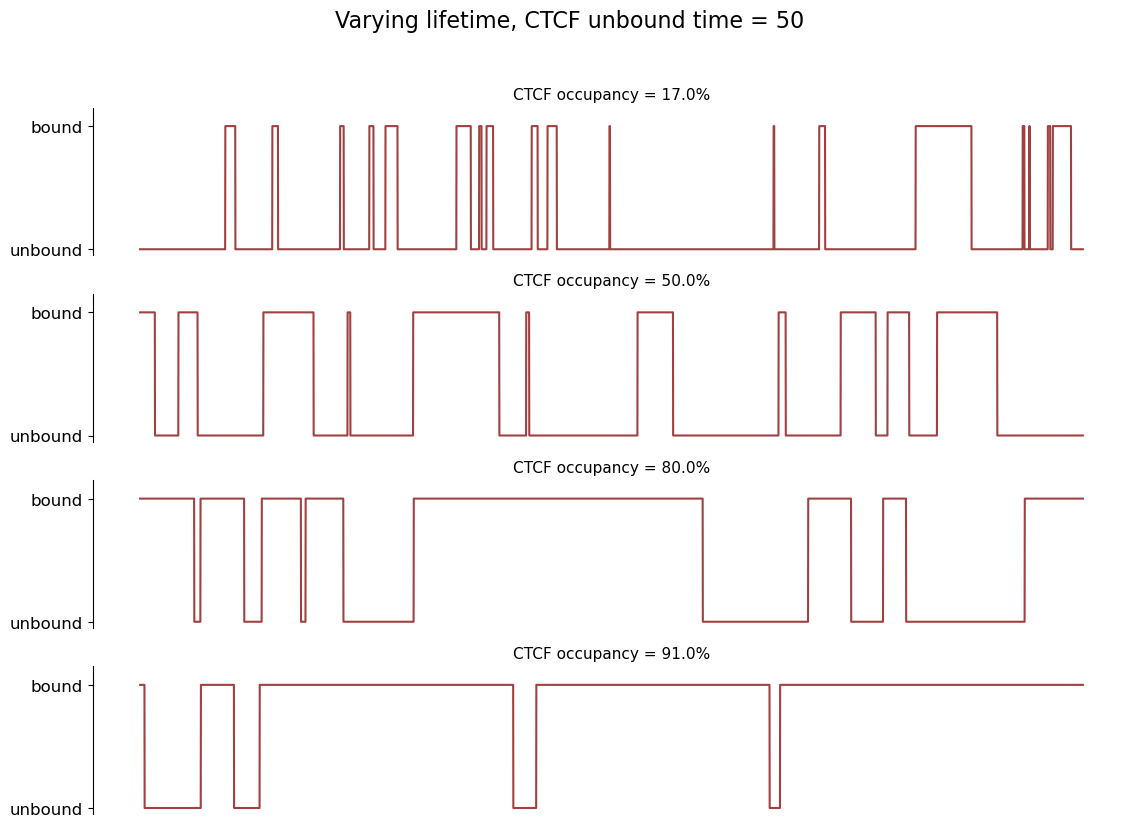

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

traj = 10000
velocity_range = [1]
lifetime_range = [500]
CTCF_life_range = [10, 50, 195, 500]

# make one figure with one row per ctcf_life
n = len(ctcf_life_range)
fig, axes = plt.subplots(nrows=n, figsize=(11.5, 2.1*n), sharex=True)
if n == 1:
    axes = [axes]  # make it iterable

for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for i, ctcf_life in enumerate(CTCF_life_range):
            ax = axes[i]

            # --- your sim setup (unchanged) ---
            paramdict_CTCF['LEF_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime'] = [ctcf_life, ctcf_life]
            paramdict_CTCF['CTCF_offtime'] = [50, 50]

            translocator = make_translocator(
                LEFTranslocatorDynamicBoundary,
                site_types,
                CTCF_left_positions,
                CTCF_right_positions,
                **paramdict_CTCF
            )

            site = []
            for _ in range(traj + 1):
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                status = int(ctcfrights[314])
                site.append(status)

            # --- plot on this axis ---
            ax.plot(site, linewidth=1.5, color='maroon', alpha=0.75)
            ax.set_ylim(-0.05, 1.15)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['unbound', 'bound'], fontsize=12)
            ax.set_xticks([])
            ax.set_title(f'CTCF occupancy = {np.round(100*ctcf_life/(ctcf_life+50))}%', fontsize=11)
            # tidy spines
            for side in ('right', 'top', 'bottom'):
                ax.spines[side].set_visible(False)

# figure-level title on top of ALL subplots
fig.suptitle('Varying lifetime, CTCF unbound time = 50', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('site_status_various_boundtime_combined.pdf', transparent=True)
plt.show()


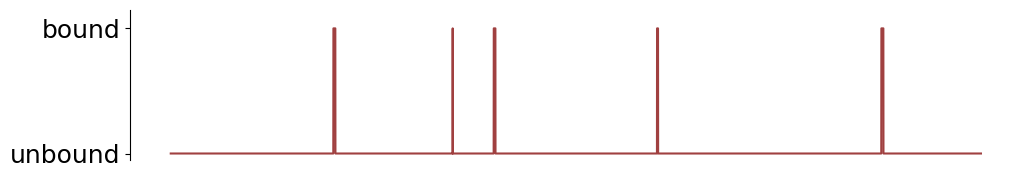

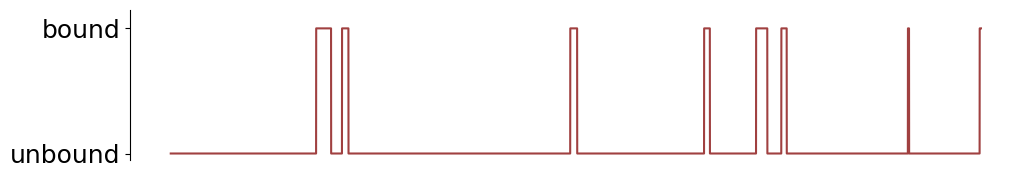

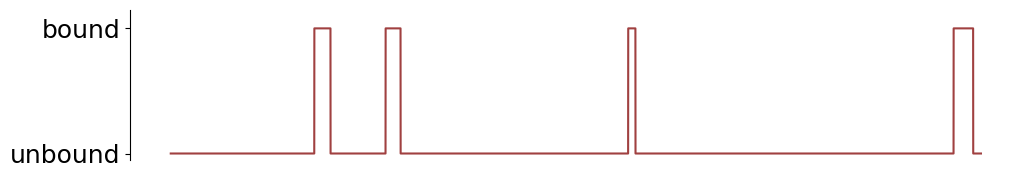

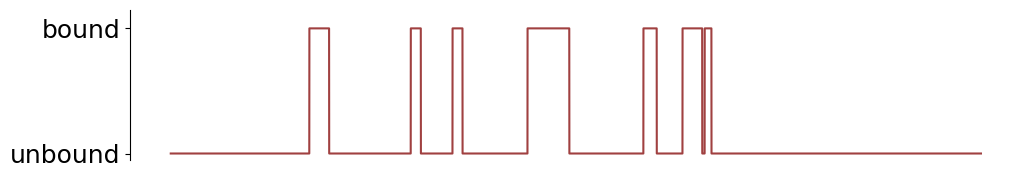

In [53]:
traj = 50000

velocity_range=[1]
lifetime_range = [500]
ctcf_life_range = [  5, 50, 100, 150]

c=1

import matplotlib as mpl
for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for ctcf_life in ctcf_life_range:
    
            paramdict_CTCF['LEF_lifetime']=[lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime']= [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime']=[ctcf_life, ctcf_life]
            paramdict_CTCF['CTCF_offtime']=[1000, 1000]
            
            ctcfrightarys = []
            ctcfleftarys = []
            translocator = make_translocator(LEFTranslocatorDynamicBoundary, 
                                                 site_types,
                                                 CTCF_left_positions,
                                                 CTCF_right_positions, 
                                                 **paramdict_CTCF)
            site = []
            for _ in range(traj+1):
                #print(_)
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                ctcflefts = np.array(translocator.stallProbLeft)
                status = int(ctcfrights[314])
                site.append(status)
                ctcfrightstrue = np.where(ctcfrights)[0]
                #print(ctcfrightstrue)
                ctcfleftstrue = np.where(ctcflefts)[0]
                ctcfrightarys.append(ctcfrightstrue)
                ctcfleftarys.append(ctcfleftstrue)
            ctcfrightary = flattened_array = np.concatenate([arr.flatten() for arr in ctcfrightarys if arr.size > 0])
            ctcfleftary = flattened_array = np.concatenate([arr.flatten() for arr in ctcfleftarys if arr.size > 0])
            ctcfs = list(ctcfrightary)#+list(ctcfleftary)
            a, b = np.histogram(ctcfs, np.arange(0,sites_per_replica,1))
            plt.figure(figsize = (11.5,1.95))
            plt.ylim(-0.05,1.15)
            plt.plot(site, linewidth = 1.5, color = 'maroon', alpha=0.75)
            plt.yticks([0, 1], ['unbound', 'bound'], fontsize = 18)  # Replace 0 and 1 with custom labels
            plt.xticks([])
            mpl.rcParams['axes.spines.right'] = False
            mpl.rcParams['axes.spines.top'] = False
            mpl.rcParams['axes.spines.bottom'] = False
            plt.savefig('site_status_for_boundtime_%s.pdf'%ctcf_life, transparent = True)
            
            plt.show()

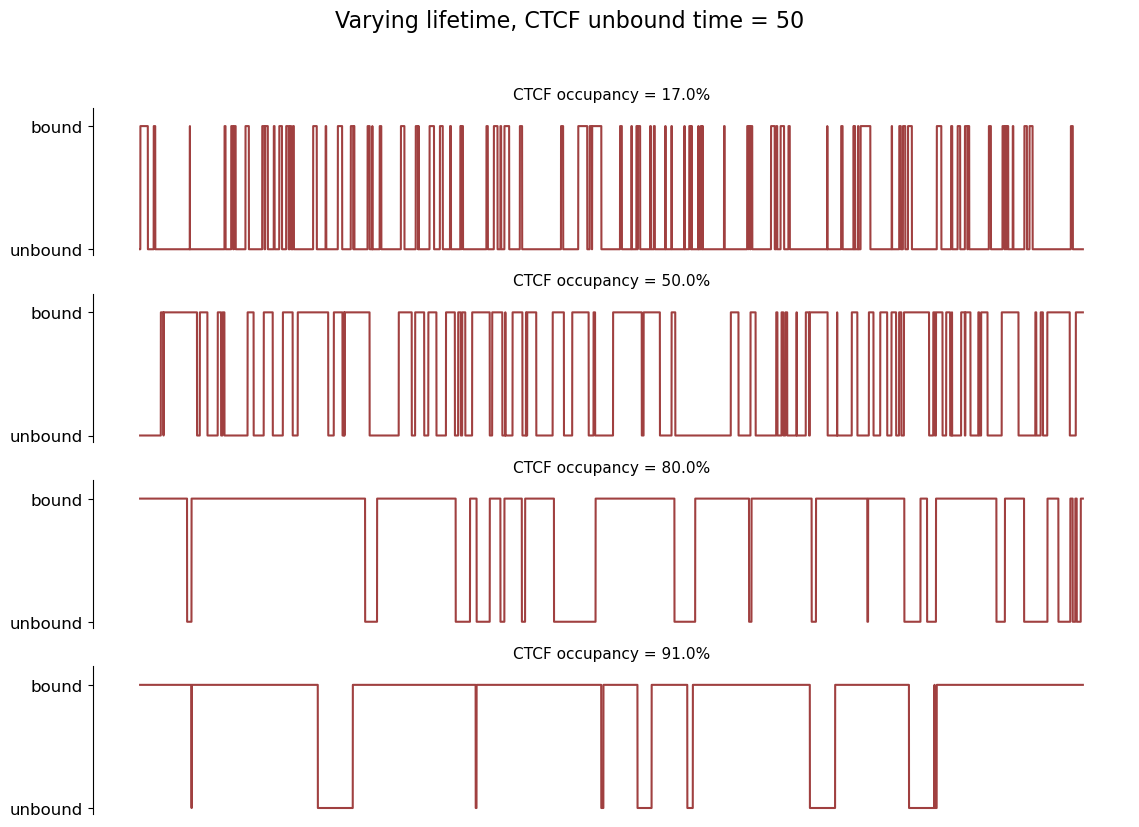

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

traj = 50000
velocity_range = [1]
lifetime_range = [1000]
CTCF_life_range = [10, 50, 195, 500]

# make one figure with one row per ctcf_life
n = len(ctcf_life_range)
fig, axes = plt.subplots(nrows=n, figsize=(11.5, 2.1*n), sharex=True)
if n == 1:
    axes = [axes]  # make it iterable

for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for i, ctcf_life in enumerate(CTCF_life_range):
            ax = axes[i]

            # --- your sim setup (unchanged) ---
            paramdict_CTCF['LEF_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime'] = [ctcf_life, ctcf_life]
            paramdict_CTCF['CTCF_offtime'] = [50, 50]

            translocator = make_translocator(
                LEFTranslocatorDynamicBoundary,
                site_types,
                CTCF_left_positions,
                CTCF_right_positions,
                **paramdict_CTCF
            )

            site = []
            for _ in range(traj + 1):
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                status = int(ctcfrights[314])
                site.append(status)

            # --- plot on this axis ---
            ax.plot(site, linewidth=1.5, color='maroon', alpha=0.75)
            ax.set_ylim(-0.05, 1.15)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['unbound', 'bound'], fontsize=12)
            ax.set_xticks([])
            ax.set_title(f'CTCF occupancy = {np.round(100*ctcf_life/(ctcf_life+50))}%', fontsize=11)
            # tidy spines
            for side in ('right', 'top', 'bottom'):
                ax.spines[side].set_visible(False)

# figure-level title on top of ALL subplots
fig.suptitle('Varying lifetime, CTCF unbound time = 50', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('site_status_various_boundtime_combined.pdf', transparent=True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

traj = 50000
velocity_range = [1]
lifetime_range = [1000]
CTCF_life_range = [10, 50, 195, 500]

# make one figure with one row per ctcf_life
n = len(ctcf_life_range)
fig, axes = plt.subplots(nrows=n, figsize=(11.5, 2.1*n), sharex=True)
if n == 1:
    axes = [axes]  # make it iterable

for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for i, ctcf_life in enumerate(CTCF_life_range):
            ax = axes[i]

            # --- your sim setup (unchanged) ---
            paramdict_CTCF['LEF_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime'] = [ctcf_life, ctcf_life]
            paramdict_CTCF['CTCF_offtime'] = [50, 50]

            translocator = make_translocator(
                LEFTranslocatorDynamicBoundary,
                site_types,
                CTCF_left_positions,
                CTCF_right_positions,
                **paramdict_CTCF
            )

            site = []
            for _ in range(traj + 1):
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                status = int(ctcfrights[314])
                site.append(status)

            # --- plot on this axis ---
            ax.plot(site, linewidth=1.5, color='maroon', alpha=0.75)
            ax.set_ylim(-0.05, 1.15)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['unbound', 'bound'], fontsize=12)
            ax.set_xticks([])
            ax.set_title(f'CTCF occupancy = {np.round(100*ctcf_life/(ctcf_life+50))}%', fontsize=11)
            # tidy spines
            for side in ('right', 'top', 'bottom'):
                ax.spines[side].set_visible(False)

# figure-level title on top of ALL subplots
fig.suptitle('Varying lifetime, CTCF unbound time = 50', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('site_status_various_boundtime_combined.pdf', transparent=True)
plt.show()


In [56]:
ctcf_occup_list = list(np.round(np.array(CTCF_life_range)/(np.array(CTCF_life_range)+50),2))
ctcf_occup_list
CTCF_unbound_range = list(np.round((1-np.array(ctcf_occup_list))*50/np.array(ctcf_occup_list),2))
CTCF_unbound_range

[244.12, 50.0, 12.5, 4.95]

In [ ]:
traj = 50000

velocity_range=[1]
lifetime_range = [500]
ctcf_life_range = [  5, 50, 500]

c=1

import matplotlib as mpl
for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for ctcf_life in ctcf_life_range:
    
            paramdict_CTCF['LEF_lifetime']=[lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime']= [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime']=[ctcf_life, ctcf_life]
            paramdict_CTCF['CTCF_offtime']=[1000, 1000]
            
            ctcfrightarys = []
            ctcfleftarys = []
            translocator = make_translocator(LEFTranslocatorDynamicBoundary, 
                                                 site_types,
                                                 CTCF_left_positions,
                                                 CTCF_right_positions, 
                                                 **paramdict_CTCF)
            site = []
            for _ in range(traj+1):
                #print(_)
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                ctcflefts = np.array(translocator.stallProbLeft)
                status = int(ctcfrights[314])
                site.append(status)
                ctcfrightstrue = np.where(ctcfrights)[0]
                #print(ctcfrightstrue)
                ctcfleftstrue = np.where(ctcflefts)[0]
                ctcfrightarys.append(ctcfrightstrue)
                ctcfleftarys.append(ctcfleftstrue)
            ctcfrightary = flattened_array = np.concatenate([arr.flatten() for arr in ctcfrightarys if arr.size > 0])
            ctcfleftary = flattened_array = np.concatenate([arr.flatten() for arr in ctcfleftarys if arr.size > 0])
            ctcfs = list(ctcfrightary)#+list(ctcfleftary)
            a, b = np.histogram(ctcfs, np.arange(0,sites_per_replica,1))
            plt.figure(figsize = (11.5,1.95))
            plt.ylim(-0.05,1.15)
            plt.plot(site, linewidth = 1.5, color = 'maroon', alpha=0.75)
            plt.yticks([0, 1], ['unbound', 'bound'], fontsize = 18)  # Replace 0 and 1 with custom labels
            plt.xticks([])
            mpl.rcParams['axes.spines.right'] = False
            mpl.rcParams['axes.spines.top'] = False
            mpl.rcParams['axes.spines.bottom'] = False
            plt.savefig('site_status_for_boundtime_%s.pdf'%ctcf_life, transparent = True)
            
            plt.show()

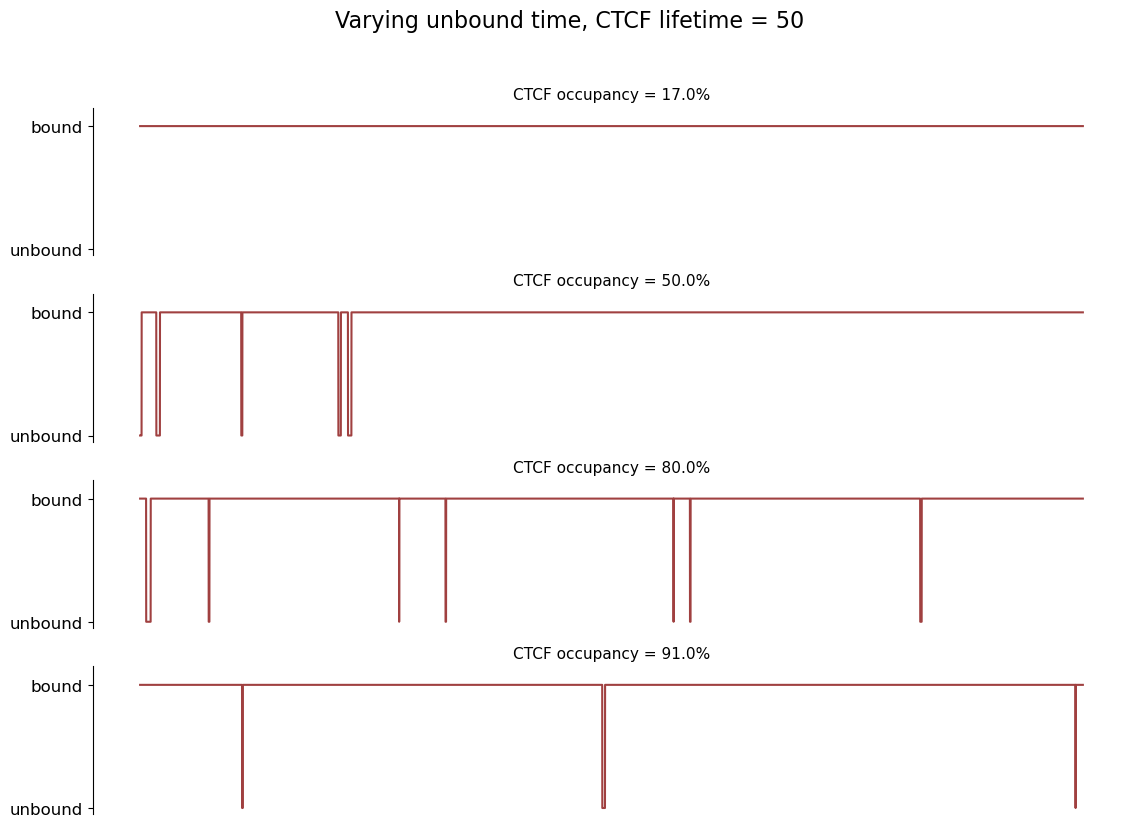

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

traj = 50000
velocity_range = [1]
lifetime_range = [500]
CTCF_unbound_range = [10, 50, 190, 500]
CTCF_unbound_range = list(np.round((1-np.array(ctcf_occup_list))*50/np.array(ctcf_occup_list),2))
# make one figure with one row per ctcf_life
n = len(ctcf_life_range)
fig, axes = plt.subplots(nrows=n, figsize=(11.5, 2.1*n), sharex=True)
if n == 1:
    axes = [axes]  # make it iterable

for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for i, unbound in enumerate(CTCF_unbound_range):
            ax = axes[i]

            # --- your sim setup (unchanged) ---
            paramdict_CTCF['LEF_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime'] = [1000, 1000]
            paramdict_CTCF['CTCF_offtime'] = [unbound, unbound]

            translocator = make_translocator(
                LEFTranslocatorDynamicBoundary,
                site_types,
                CTCF_left_positions,
                CTCF_right_positions,
                **paramdict_CTCF
            )

            site = []
            for _ in range(traj + 1):
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                status = int(ctcfrights[314])
                site.append(status)

            # --- plot on this axis ---
            ax.plot(site, linewidth=1.5, color='maroon', alpha=0.75)
            ax.set_ylim(-0.05, 1.15)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['unbound', 'bound'], fontsize=12)
            ax.set_xticks([])
            ax.set_title(f'CTCF occupancy = {np.round(100*50/(unbound+50))}%', fontsize=11)
            # tidy spines
            for side in ('right', 'top', 'bottom'):
                ax.spines[side].set_visible(False)

# figure-level title on top of ALL subplots
fig.suptitle('Varying unbound time, CTCF lifetime = 50', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('site_status_various_unboundtime_combined.pdf', transparent=True)
plt.show()


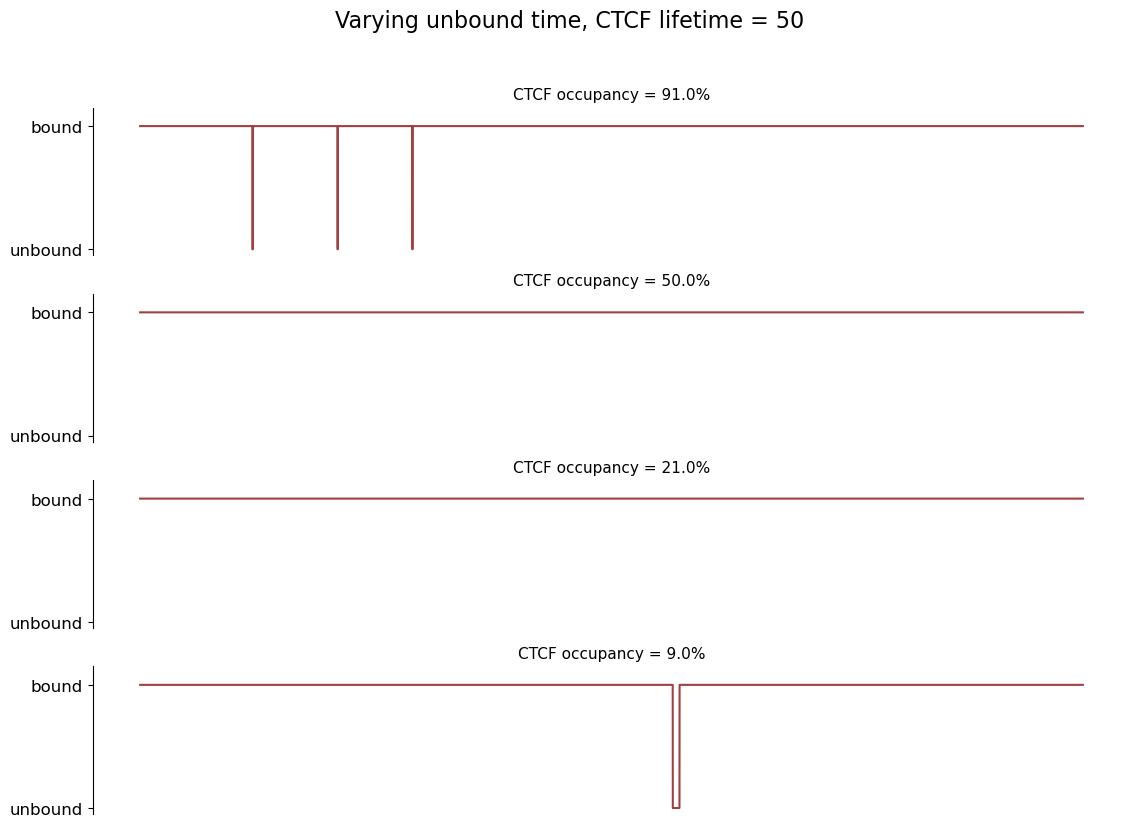

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

traj = 80000
velocity_range = [1]
lifetime_range = [1000]
CTCF_unbound_range = [5, 50, 190, 500]
CTCF_unbound_range = list(np.round((1-np.array(ctcf_occup_list))*50/np.array(ctcf_occup_list),2))
# make one figure with one row per ctcf_life
n = len(ctcf_life_range)
fig, axes = plt.subplots(nrows=n, figsize=(11.5, 2.1*n), sharex=True)
if n == 1:
    axes = [axes]  # make it iterable
CTCF_unbound_range = [5, 50, 190, 500]
for lifetime_val in lifetime_range:
    for velocity_val in velocity_range:
        for i, unbound in enumerate(CTCF_unbound_range):
            ax = axes[i]

            # --- your sim setup (unchanged) ---
            paramdict_CTCF['LEF_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['velocity_multiplier'] = velocity_val
            paramdict_CTCF['LEF_stalled_lifetime'] = [lifetime_val, lifetime_val]
            paramdict_CTCF['CTCF_lifetime'] = [5000, 5000]
            paramdict_CTCF['CTCF_offtime'] = [unbound, unbound]

            translocator = make_translocator(
                LEFTranslocatorDynamicBoundary,
                site_types,
                CTCF_left_positions,
                CTCF_right_positions,
                **paramdict_CTCF
            )

            site = []
            for _ in range(traj + 1):
                translocator.step()
                ctcfrights = np.array(translocator.stallProbRight)
                status = int(ctcfrights[314])
                site.append(status)

            # --- plot on this axis ---
            ax.plot(site, linewidth=1.5, color='maroon', alpha=0.75)
            ax.set_ylim(-0.05, 1.15)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['unbound', 'bound'], fontsize=12)
 
            ax.set_xticks([])
            
            ax.set_title(f'CTCF occupancy = {np.round(100*50/(unbound+50))}%', fontsize=11)
            # tidy spines
            for side in ('right', 'top', 'bottom'):
                ax.spines[side].set_visible(False)

# figure-level title on top of ALL subplots
fig.suptitle('Varying unbound time, CTCF lifetime = 50', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('site_status_various_unboundtime_combined.pdf', transparent=True)
plt.show()


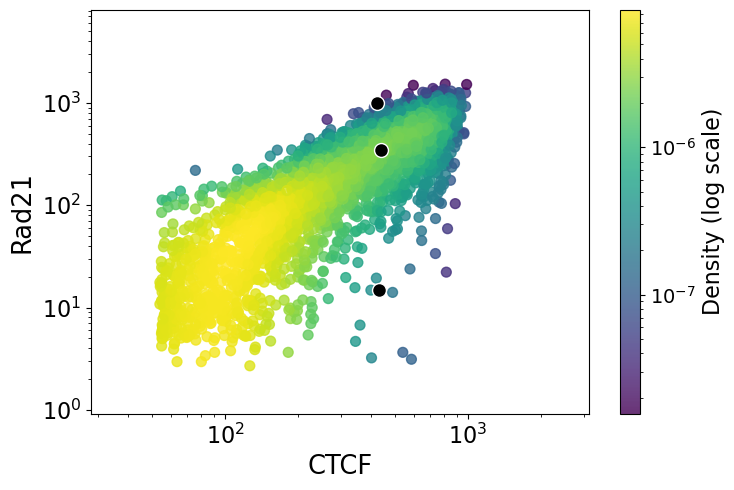

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
file['ctcf'] = file['ctcf']*ctcfnormalizer*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']*rad21normalizer
x = file['ctcf']
y= file['Rad21']

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21']
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(28, 3150)
plt.ylim(0.92, 8100)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


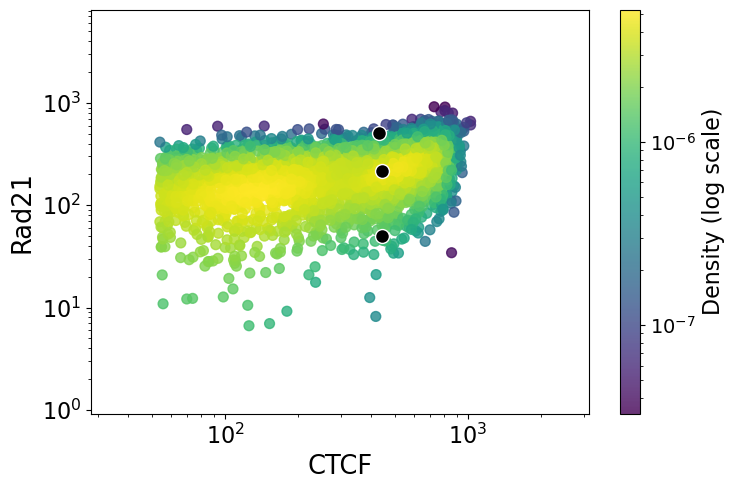

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_conf_newtot.csv')
file['ctcf'] = file['ctcf']*ctcfnormalizer*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']*rad21normalizer
x = file['ctcf']
y= file['Rad21']

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21']
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(28, 3150)
plt.ylim(0.92, 8100)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


In [ ]:
# Data
# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
file['ctcf'] = file['ctcf']*ctcfnormalizer*10*0.308 #factor of 10 is for replica
file['Rad21'] = file['Rad21']*rad21normalizer
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]
x = np.arange(len(ctcf_s))

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

sigma = 0.051  # Constant width
offset = 0.075

# Plot Rad21 (top)
for i, val in enumerate(rad_s):
    mu = x[i] + offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax1.fill_between(x_fine, y, 0, color='green', alpha=0.9, label='Rad21' if i == 0 else "")
ax1.set_ylabel('Rad21', fontsize=15)
ax1.legend(fontsize=12)

# Plot CTCF (bottom)
for i, val in enumerate(ctcf_s):
    mu = x[i] - offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax2.fill_between(x_fine, y, 0, color='blue', alpha=0.9, label='CTCF' if i == 0 else "")
ax2.set_ylabel('CTCF', fontsize=14)
ax2.legend(fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Peak {i+1}' for i in x], fontsize=12)
ax2.set_xlabel('Peaks', fontsize=15)

plt.tight_layout()
plt.savefig('figures/peaks.pdf')
plt.show()


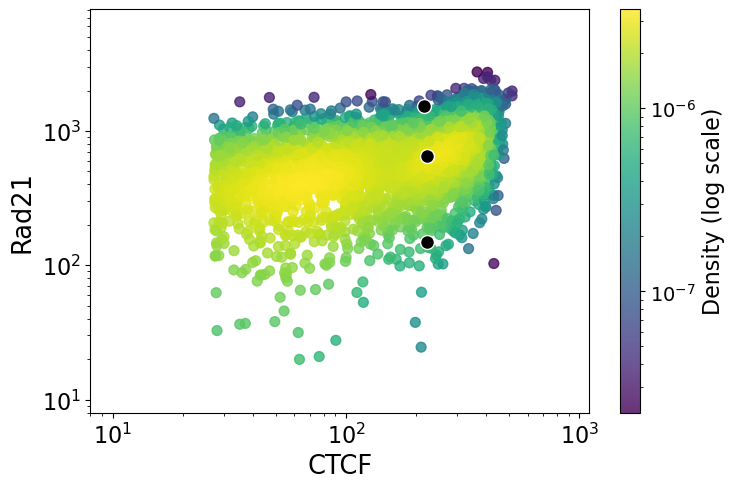

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_conf_newtot.csv')
x = file['ctcf']*ctcfnormalizer
y = file['Rad21']*rad21normalizer

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21']*rad21normalizer
rounded_file['ctcf_reads'] = rounded_file['ctcf']*ctcfnormalizer

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(8, 1100)
plt.ylim(8, 8100)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
x = file['ctcf']
y = file['Rad21']

# Add derived columns
rounded_file = file.copy()  # Assuming 'file' is the correct dataframe
rounded_file['reads'] = rounded_file['Rad21'] 
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

# Data
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=100, alpha=0.8)
cbar = plt.colorbar(sc, label='Density (log scale)')

# Adjust the colorbar label font size
cbar.set_label('Density (log scale)', fontsize=16)

# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 41000)
plt.ylim(59, 115000)

# Adjust colorbar ticks' font size
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


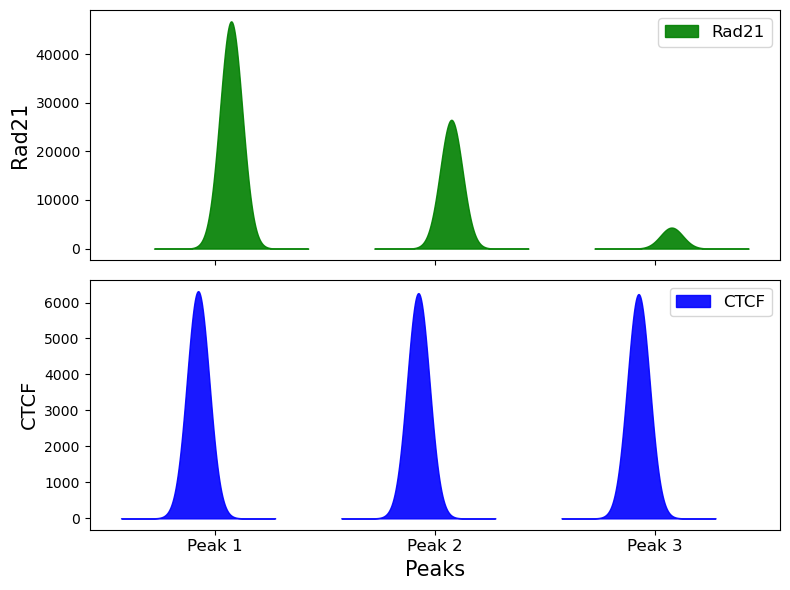

In [60]:
# Data
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]
x = np.arange(len(ctcf_s))

# Gaussian function (normalized area)
def gaussian_area(x_vals, mu, sigma, area):
    return area * np.exp(-0.5 * ((x_vals - mu) / sigma)**2)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

sigma = 0.051  # Constant width
offset = 0.075

# Plot Rad21 (top)
for i, val in enumerate(rad_s):
    mu = x[i] + offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax1.fill_between(x_fine, y, 0, color='green', alpha=0.9, label='Rad21' if i == 0 else "")
ax1.set_ylabel('Rad21', fontsize=15)
ax1.legend(fontsize=12)

# Plot CTCF (bottom)
for i, val in enumerate(ctcf_s):
    mu = x[i] - offset
    x_fine = np.linspace(mu - 0.35, mu + 0.35, 5000)
    y = gaussian_area(x_fine, mu, sigma, val)
    ax2.fill_between(x_fine, y, 0, color='blue', alpha=0.9, label='CTCF' if i == 0 else "")
ax2.set_ylabel('CTCF', fontsize=14)
ax2.legend(fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Peak {i+1}' for i in x], fontsize=12)
ax2.set_xlabel('Peaks', fontsize=15)

plt.tight_layout()
plt.savefig('figures/peaks.pdf')
plt.show()


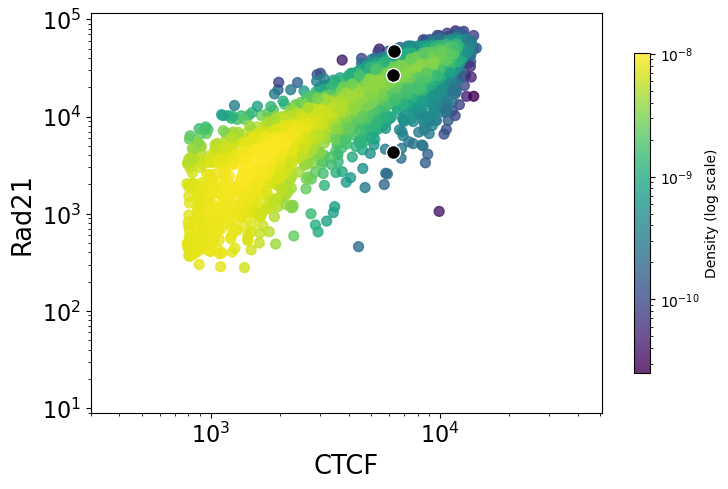

In [56]:
# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
x = file['ctcf']
y = file['Rad21'] 

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)


# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Optionally add a legend
#plt.legend(fontsize=14, loc='upper left')


# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot.pdf')
plt.show()


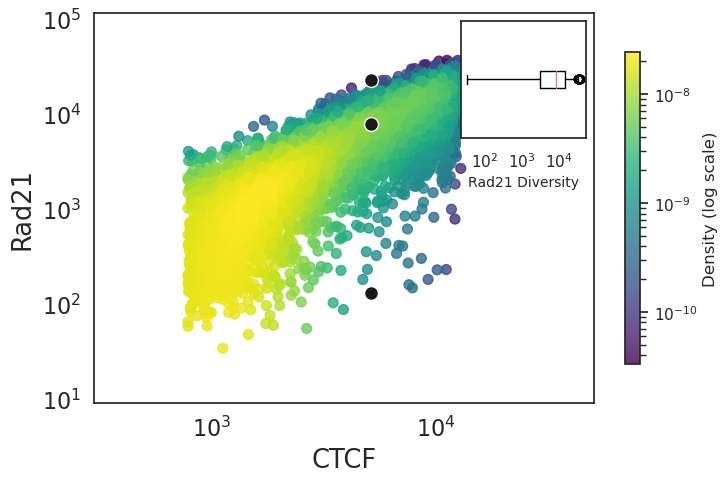

In [36]:
# Add a small inset axis to show y diversity
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5)

plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)

# Add boxplot inset
axins = inset_axes(plt.gca(), width="25%", height="30%", loc='upper right')
axins.boxplot(y, vert=False)
axins.set_xscale('log')
axins.set_yticks([])
axins.set_xlabel('Rad21 Diversity', fontsize=10)

plt.tight_layout()
plt.show()


In [41]:
# Define the file pattern
file_pattern = "Rad21_vs_ctcf_reads_random_mod_a_w_chr1*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)

# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_conf.csv', index=False)

In [42]:
df_merged

,Rad21,ctcf
0,7631,5150.950414
1,15974,5150.950414
2,7897,5150.950414
3,16084,5150.950414
4,7561,5150.950414
...,...,...
9059,12210,5150.950414
9060,16787,5150.950414
9061,1634,5150.950414
9062,20613,5150.950414


In [43]:
file = df_merged
rounded_file = file.round()

# Add derived columns
rounded_file['reads'] = rounded_file['Rad21'] / 2
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

#print(subset)
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

print(f'Max reads is {max_read} and ctcf_reads is {ctcf_max}')
print(f'Median reads value: {median_read}')
print(f'Corresponding ctcf_reads value: {ctcf_for_median_read}')

Max reads is 22954.0 and ctcf_reads is 5151.0
Median reads value: 7833.75
Corresponding ctcf_reads value: 5151.0


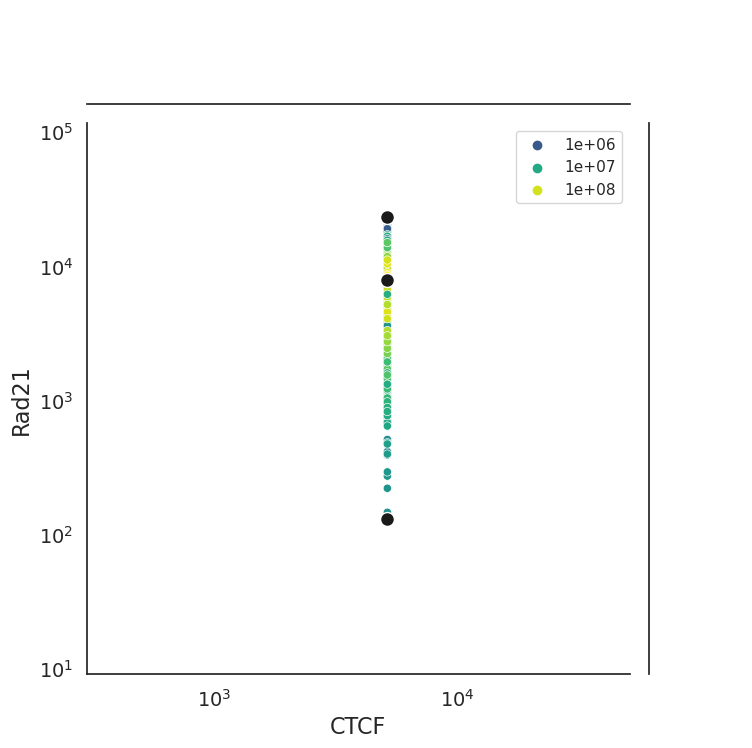

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Your existing data
file = df_merged
x = file['ctcf']
y = file['Rad21'] / 2

mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Create joint plot
sns.set(style="white")
g = sns.jointplot(
    x=x, y=y, kind="scatter",
    hue=z, palette="viridis", hue_norm=plt.matplotlib.colors.LogNorm(),
    marginal_kws=dict(bins=40, fill=True),
    height=7.5
)

# Add log scale
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_joint.set_xlim(300, 51000)
g.ax_joint.set_ylim(9, 115000)
g.ax_joint.set_xlabel("CTCF", fontsize=16)
g.ax_joint.set_ylabel("Rad21", fontsize=16)
g.ax_joint.tick_params(labelsize=14)

# Overlay special points
g.ax_joint.scatter(
    ctcf_s, rad_s,
    color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points'
)


In [6]:
# Define the file pattern
file_pattern = "Rad21_vs_ctcf_reads_random_mod_a_w_conf_chr1*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)

# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_confboundtime_unboundchange.csv', index=False)

In [7]:
file = df_merged
rounded_file = file.round()

# Add derived columns
rounded_file['reads'] = rounded_file['Rad21'] / 2
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

#print(subset)
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

print(f'Max reads is {max_read} and ctcf_reads is {ctcf_max}')
print(f'Median reads value: {median_read}')
print(f'Corresponding ctcf_reads value: {ctcf_for_median_read}')

Max reads is 16160.5 and ctcf_reads is 6130.0
Median reads value: 6723.0
Corresponding ctcf_reads value: 6173.0


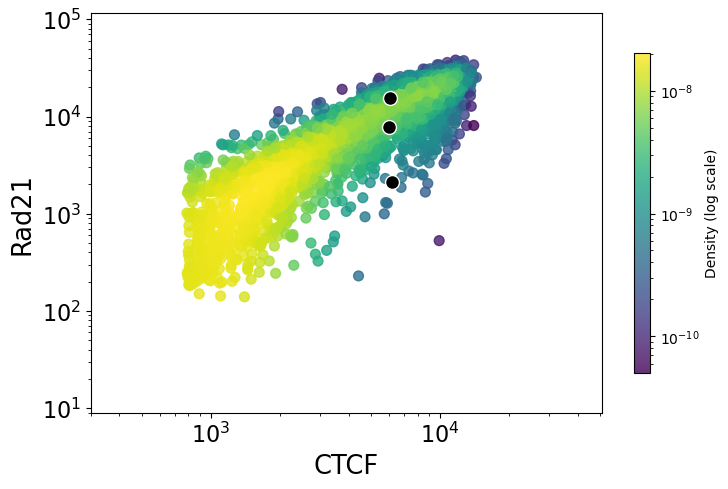

In [10]:
# Example data (replace with your real DataFrame)
file = df_merged
x = file['ctcf']
y = file['Rad21'] / 2

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)


# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Optionally add a legend
#plt.legend(fontsize=14, loc='upper left')


# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot_conf.pdf')
plt.show()


16
Max reads is 15676.5 and ctcf_reads is 6034.0
Median reads value: 7721.75
Corresponding ctcf_reads value: 6011.0


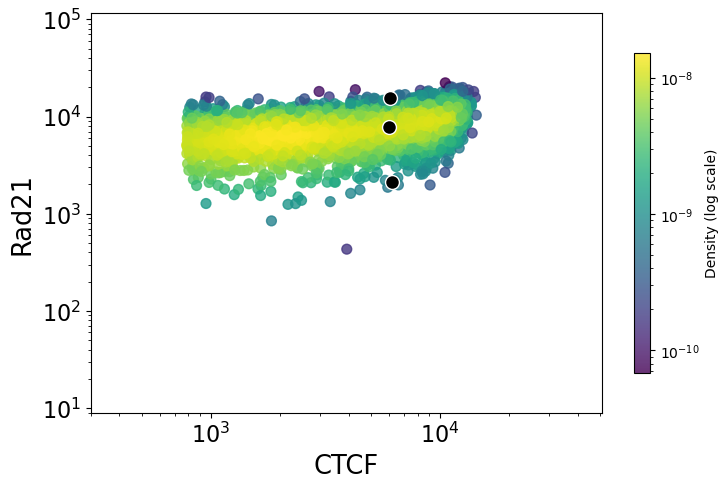

In [11]:
# Define the file pattern
file_pattern = "data/Rad21_vs_ctcf_reads_random_mod_a_w_conf_*.csv"

# Get a list of all matching file paths
csv_files = glob.glob(file_pattern)
print(len(csv_files))
# Read and concatenate all CSV files into a single DataFrame
df_merged = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df_merged.to_csv('Rad21_vs_ctcf_reads_confboundtime_unboundchange_newtot.csv', index=False)
file = df_merged
rounded_file = file.round()

# Add derived columns
rounded_file['reads'] = rounded_file['Rad21'] / 2
rounded_file['ctcf_reads'] = rounded_file['ctcf']

# Compute average of ctcf_reads
avg_ctcf = rounded_file['ctcf_reads'].mean()

# Calculate ±5% bounds
lower_bound = avg_ctcf * 0.975
upper_bound = avg_ctcf * 1.025

# Filter rows within ±5% of the average
subset = rounded_file[(rounded_file['ctcf_reads'] >= lower_bound) & (rounded_file['ctcf_reads'] <= upper_bound)]

#print(subset)
max_read = subset['reads'].max()
median_read = subset['reads'].median()
min_read = subset['reads'].min()

# Find the row where 'reads' is closest to the median_read
closest_index = (subset['reads'] - median_read).abs().idxmin()

# Get the corresponding ctcf_reads values (as scalars)
ctcf_max = subset.loc[subset['reads'] == max_read, 'ctcf_reads'].values[0]
ctcf_for_median_read = subset.loc[closest_index, 'ctcf_reads']
ctcf_min = subset.loc[subset['reads'] == min_read, 'ctcf_reads'].values[0]

print(f'Max reads is {max_read} and ctcf_reads is {ctcf_max}')
print(f'Median reads value: {median_read}')
print(f'Corresponding ctcf_reads value: {ctcf_for_median_read}')
# Example data (replace with your real DataFrame)
file = df_merged
x = file['ctcf']
y = file['Rad21'] / 2

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)


# Define your special points
ctcf_s = [ctcf_max, ctcf_for_median_read, ctcf_min]
rad_s = [max_read, median_read, min_read]

# Overlay them on the existing scatter plot
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5, label='Highlighted points')

# Optionally add a legend
#plt.legend(fontsize=14, loc='upper left')


# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot_conf.pdf')
plt.show()


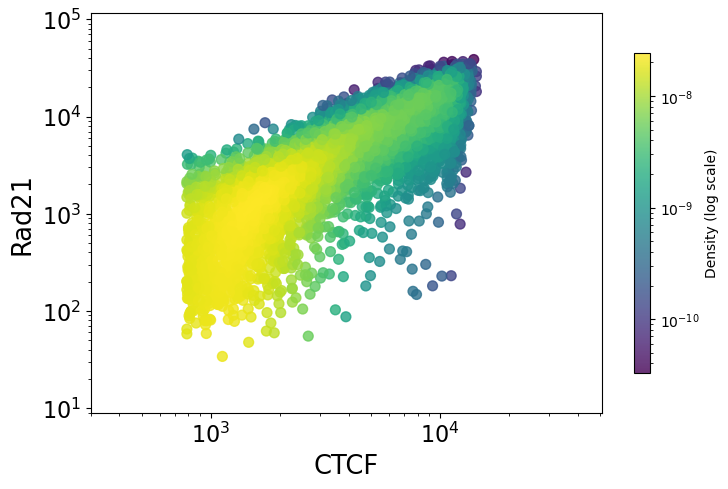

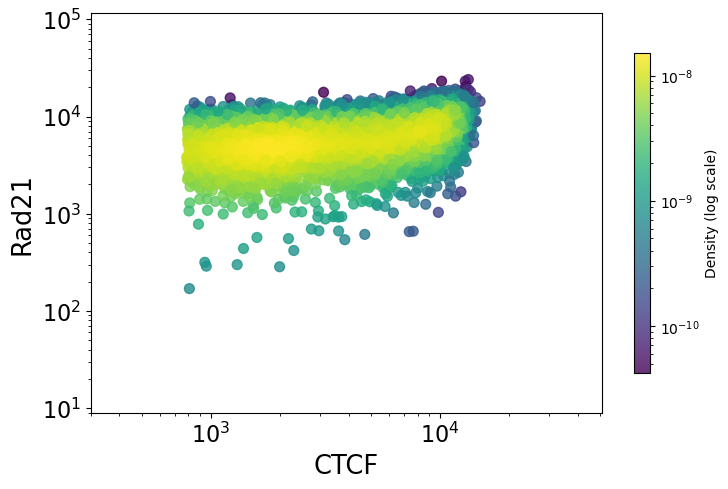

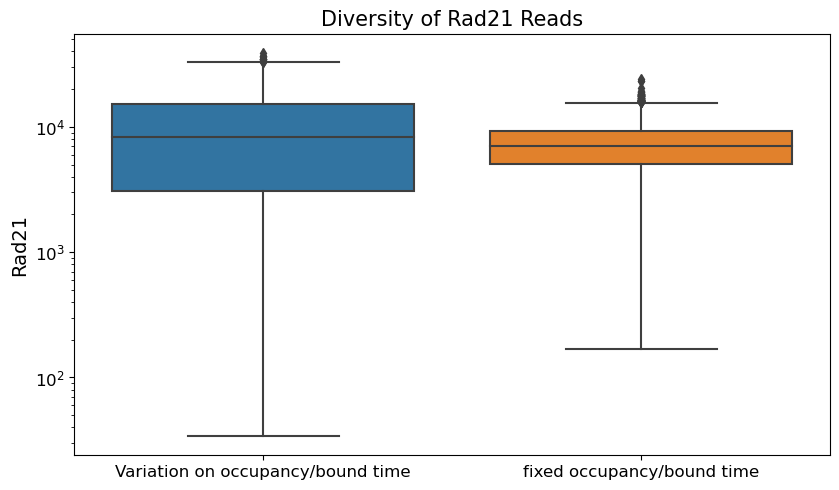

In [18]:
# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads.csv')
df1=file
x = file['ctcf']
y = file['Rad21'] / 2

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)
# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot_conf.pdf')
plt.show()

# Example data (replace with your real DataFrame)
file = pd.read_csv('Rad21_vs_ctcf_reads_confboundtime_unboundchange.csv')
df2=file
x = file['ctcf']
y = file['Rad21'] / 2

# Remove non-positive values before log scale
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Stack and compute point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # Density estimate for each point

# Plot
plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)
# Axis labels and scales
plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)
plt.tight_layout()
plt.savefig('figures/scatterplot_conf.pdf')
plt.show()
# Load your datasets

# Optional: If Rad21 needs to be divided by 2 (as in earlier examples)
df1['Rad21'] = df1['Rad21'] / 2
df2['Rad21'] = df2['Rad21'] / 2

# Create a new DataFrame combining both, with a label column
df1['Group'] = 'Variation on bound time'
df2['Group'] = 'fixed bound time'

# Combine into one DataFrame for plotting
combined_df = pd.concat([df1[['Rad21', 'Group']], df2[['Rad21', 'Group']]])

# Plot
plt.figure(figsize=(8.5, 5))
sns.boxplot(data=combined_df, x='Group', y='Rad21')

plt.yscale('log')  # If needed to show spread better
plt.ylabel('Rad21', fontsize=14)
plt.xlabel('', fontsize=14)
plt.title('Diversity of Rad21 Reads', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
df1['Rad21'].median()

8356.5

In [33]:
df2['Rad21'].median()

6978.0

In [39]:
# Calculate summary statistics for each group
for group in combined_df['Group'].unique():
    group_data = combined_df[combined_df['Group'] == group]['Rad21']
    median = group_data.median()
    q1 = group_data.quantile(0.25)
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1
    print(f"Group: {group}")
    print(f"Median: {median}")
    print(f"25th Percentile (Q1): {q1}")
    print(f"75th Percentile (Q3): {q3}")
    print(f"IQR: {iqr}")
    print("------")

Group: Variation on bound time
Median: 16713.0
25th Percentile (Q1): 6152.5
75th Percentile (Q3): 30231.0
IQR: 24078.5
------
Group: Fixed bound time
Median: 13956.0
25th Percentile (Q1): 10032.0
75th Percentile (Q3): 18545.25
IQR: 8513.25
------


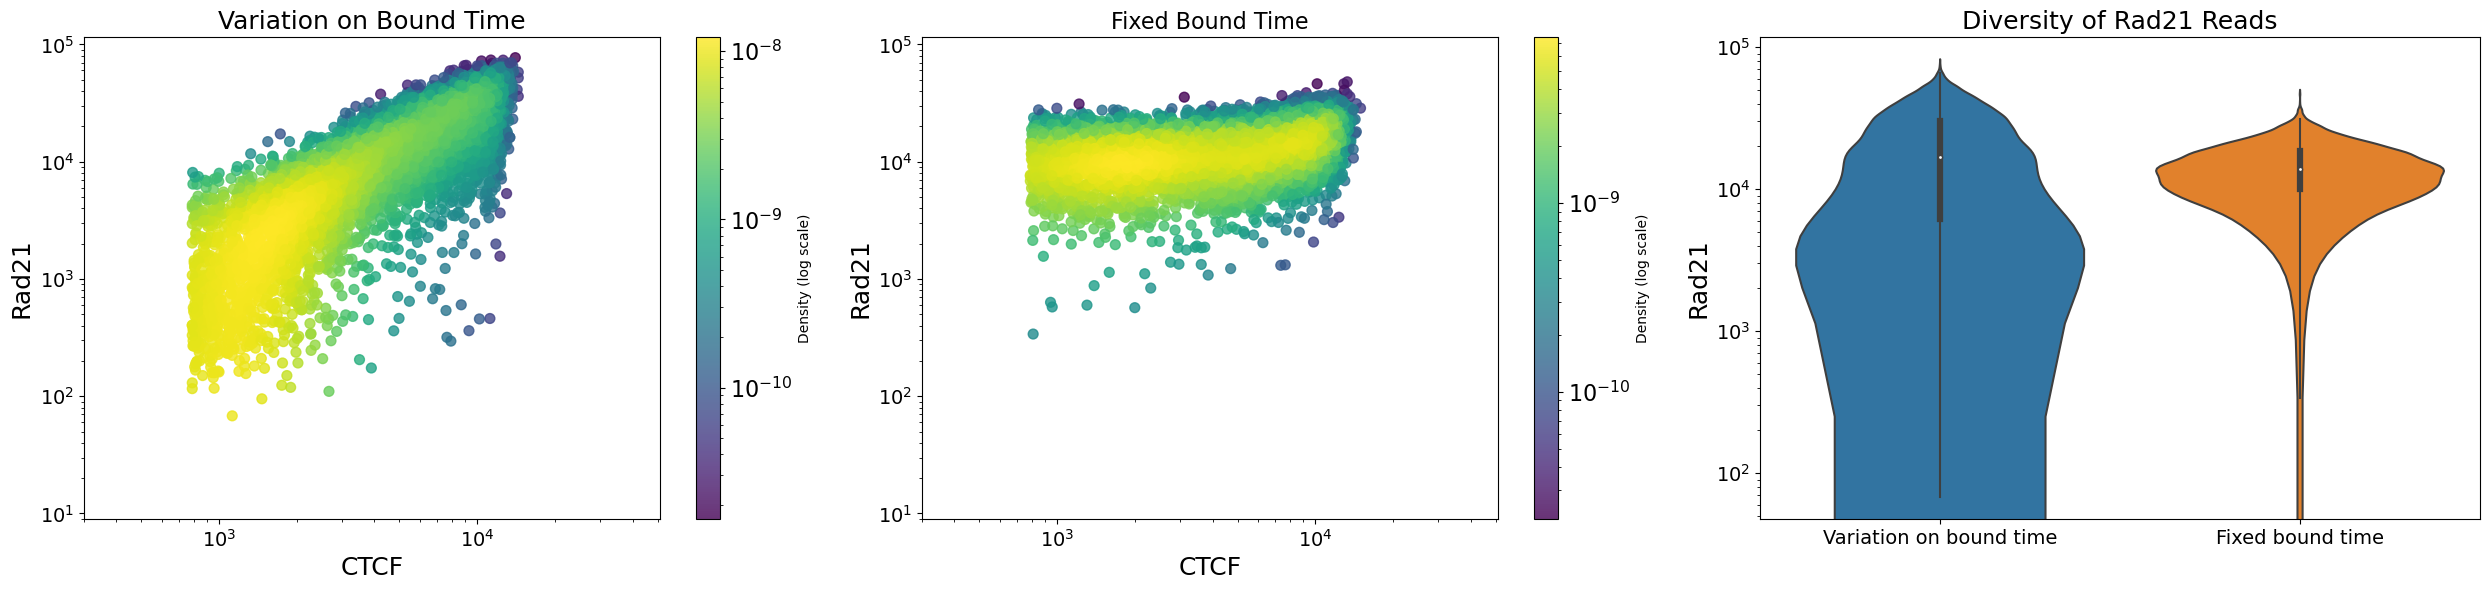

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Load your datasets
# Replace these paths with the actual paths to your CSV files
file1 = pd.read_csv('data/newdata/Rad21_vs_ctcf_reads.csv')
file2 = pd.read_csv('data/newdata/Rad21_vs_ctcf_reads_confboundtime_unboundchange.csv')

# Optional: If Rad21 needs to be divided by 2 (as in earlier examples)
file1['Rad21'] = file1['Rad21']# / 2
file2['Rad21'] = file2['Rad21']# / 2

# Remove non-positive values before log scale
x1 = file1['ctcf']
y1 = file1['Rad21']
mask1 = (x1 > 0) & (y1 > 0)
x1 = x1[mask1]
y1 = y1[mask1]

x2 = file2['ctcf']
y2 = file2['Rad21']
mask2 = (x2 > 0) & (y2 > 0)
x2 = x2[mask2]
y2 = y2[mask2]

# Stack and compute point density for both datasets
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)  # Density estimate for each point

xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)  # Density estimate for each point

# Create a new DataFrame combining both, with a label column
file1['Group'] = 'Variation on bound time'
file2['Group'] = 'Fixed bound time'

combined_df = pd.concat([file1[['Rad21', 'Group']], file2[['Rad21', 'Group']]])

# Set up a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Scatter plot for df1 (Variation on bound time) on column 1
sc1 = axes[0].scatter(x1, y1, c=z1, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('CTCF', fontsize=18)
axes[0].set_ylabel('Rad21', fontsize=18)
axes[0].set_title('Variation on Bound Time', fontsize=18)
axes[0].set_xlim(300, 51000)
axes[0].set_ylim(9, 115000)
cbar1= fig.colorbar(sc1, ax=axes[0], label='Density (log scale)')
cbar1.ax.tick_params(labelsize= 16)
axes[0].tick_params(axis='both', labelsize=14)

# Scatter plot for df2 (Fixed bound time) on column 2
sc2 = axes[1].scatter(x2, y2, c=z2, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('CTCF', fontsize=18)
axes[1].set_ylabel('Rad21', fontsize=18)
axes[1].set_title('Fixed Bound Time', fontsize=16)
axes[1].set_xlim(300, 51000)
axes[1].set_ylim(9, 115000)
cbar2= fig.colorbar(sc2, ax=axes[1], label='Density (log scale)')
cbar2.ax.tick_params(labelsize= 16)
axes[1].tick_params(axis='both', labelsize=14)

# Violin plot in column 3
sns.violinplot(data=combined_df, x='Group', y='Rad21', ax=axes[2], scale='width')
axes[2].set_yscale('log')
axes[2].set_xlabel('', fontsize=18)
axes[2].set_ylabel('Rad21', fontsize=18)
axes[2].set_title('Diversity of Rad21 Reads', fontsize=18)
axes[2].tick_params(axis='both', labelsize=14)
# Adjust layout for better spacing
plt.tight_layout()

plt.savefig('summary.pdf',dpi=500)
# Show plot
plt.show()


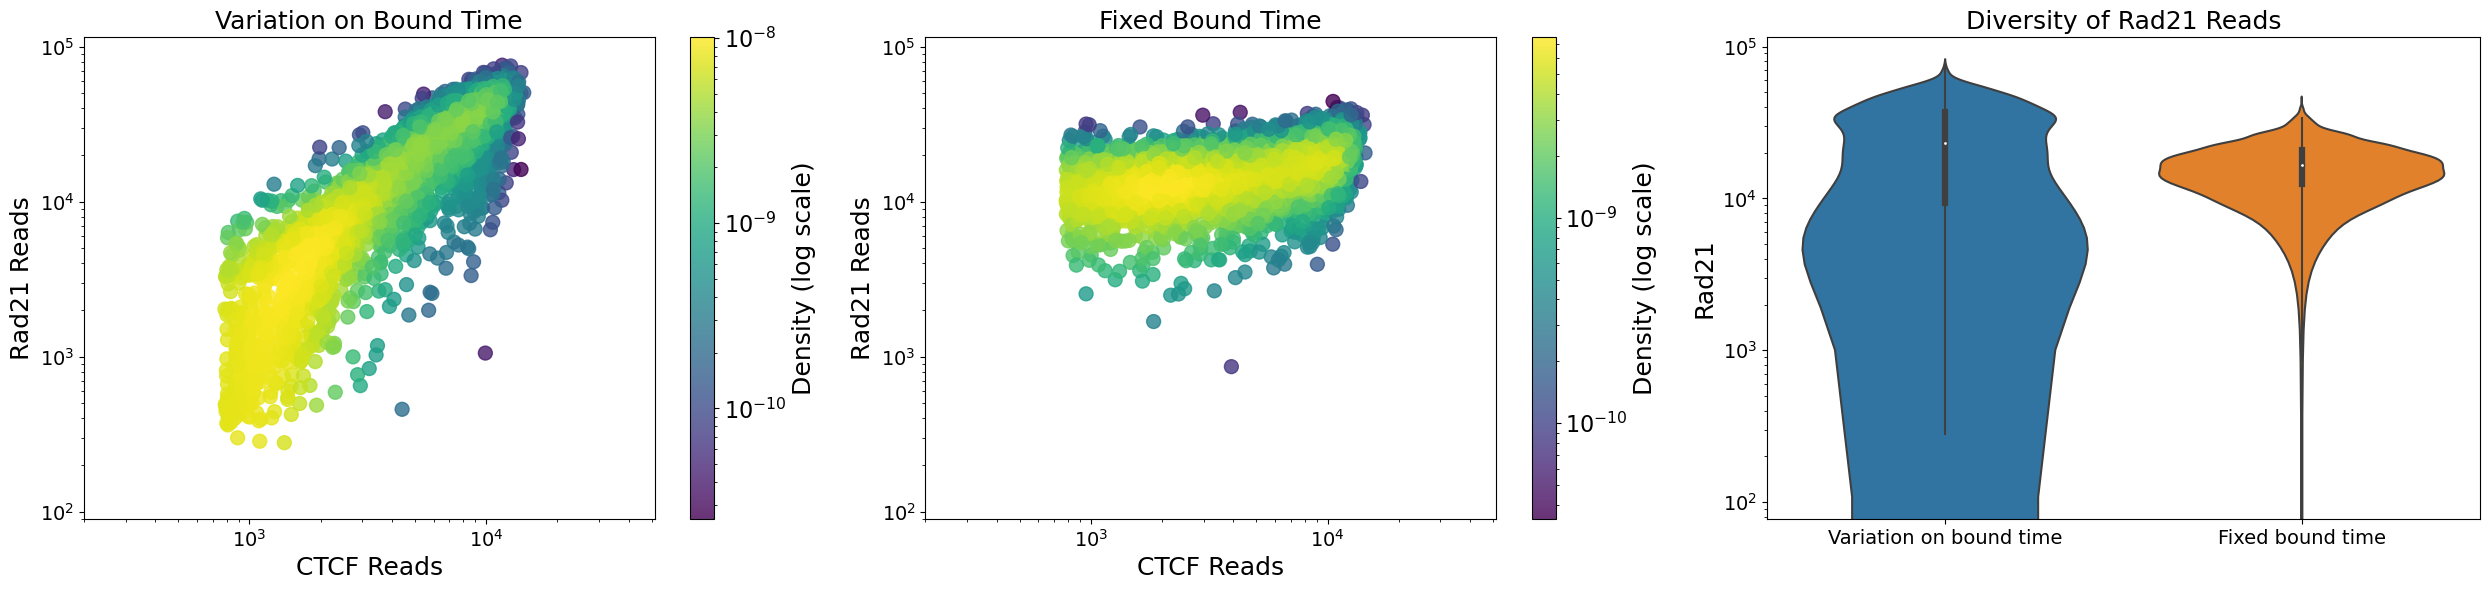

In [39]:
# Load your datasets
# Replace these paths with the actual paths to your CSV files
file1 = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
file2 = pd.read_csv('Rad21_vs_ctcf_reads_confboundtime_unboundchange_newtot.csv')

# Optional: If Rad21 needs to be divided by 2 (as in earlier examples)
file1['Rad21'] = file1['Rad21']  # / 2
file2['Rad21'] = file2['Rad21']  # / 2

# Remove non-positive values before log scale
x1 = file1['ctcf']
y1 = file1['Rad21']
mask1 = (x1 > 0) & (y1 > 0)
x1 = x1[mask1]
y1 = y1[mask1]

x2 = file2['ctcf']
y2 = file2['Rad21']
mask2 = (x2 > 0) & (y2 > 0)
x2 = x2[mask2]
y2 = y2[mask2]

# Stack and compute point density for both datasets
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)  # Density estimate for each point

xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)  # Density estimate for each point

# Create a new DataFrame combining both, with a label column
file1['Group'] = 'Variation on bound time'
file2['Group'] = 'Fixed bound time'

combined_df = pd.concat([file1[['Rad21', 'Group']], file2[['Rad21', 'Group']]])

# Font sizes (easy to adjust these values)
axis_label_size = 18
tick_label_size = 14
colorbar_tick_size = 16
colorbar_label_size = 18  # Adjust the font size for the colorbar label
title_size = 18

# Set up a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Scatter plot for df1 (Variation on bound time) on column 1
sc1 = axes[0].scatter(x1, y1, c=z1, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=100, alpha=0.8)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('CTCF Reads', fontsize=axis_label_size)
axes[0].set_ylabel('Rad21 Reads', fontsize=axis_label_size)
axes[0].set_title('Variation on Bound Time', fontsize=title_size)
axes[0].set_ylim(90, 115000)
axes[0].set_xlim(200, 51500)
cbar1 = fig.colorbar(sc1, ax=axes[0], label='Density (log scale)')
cbar1.ax.tick_params(labelsize=colorbar_tick_size)
cbar1.set_label('Density (log scale)', fontsize=colorbar_label_size)  # Set colorbar label font size
axes[0].tick_params(axis='both', labelsize=tick_label_size)

# Scatter plot for df2 (Fixed bound time) on column 2
sc2 = axes[1].scatter(x2, y2, c=z2, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=100, alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('CTCF Reads', fontsize=axis_label_size)
axes[1].set_ylabel('Rad21 Reads', fontsize=axis_label_size)
axes[1].set_title('Fixed Bound Time', fontsize=title_size)
axes[1].set_ylim(90, 115000)
axes[1].set_xlim(200, 51500)
cbar2 = fig.colorbar(sc2, ax=axes[1], label='Density (log scale)')
cbar2.ax.tick_params(labelsize=colorbar_tick_size)
cbar2.set_label('Density (log scale)', fontsize=colorbar_label_size)  # Set colorbar label font size
axes[1].tick_params(axis='both', labelsize=tick_label_size)

# Violin plot in column 3
sns.violinplot(data=combined_df, x='Group', y='Rad21', ax=axes[2], scale='width')
axes[2].set_yscale('log')
axes[2].set_xlabel('', fontsize=axis_label_size)
axes[2].set_ylabel('Rad21', fontsize=axis_label_size)
axes[2].set_title('Diversity of Rad21 Reads', fontsize=title_size)
axes[2].tick_params(axis='both', labelsize=tick_label_size)

# Adjust layout for better spacing
plt.tight_layout()

# Save and show plot
plt.savefig('summary.pdf', dpi=500)
plt.show()


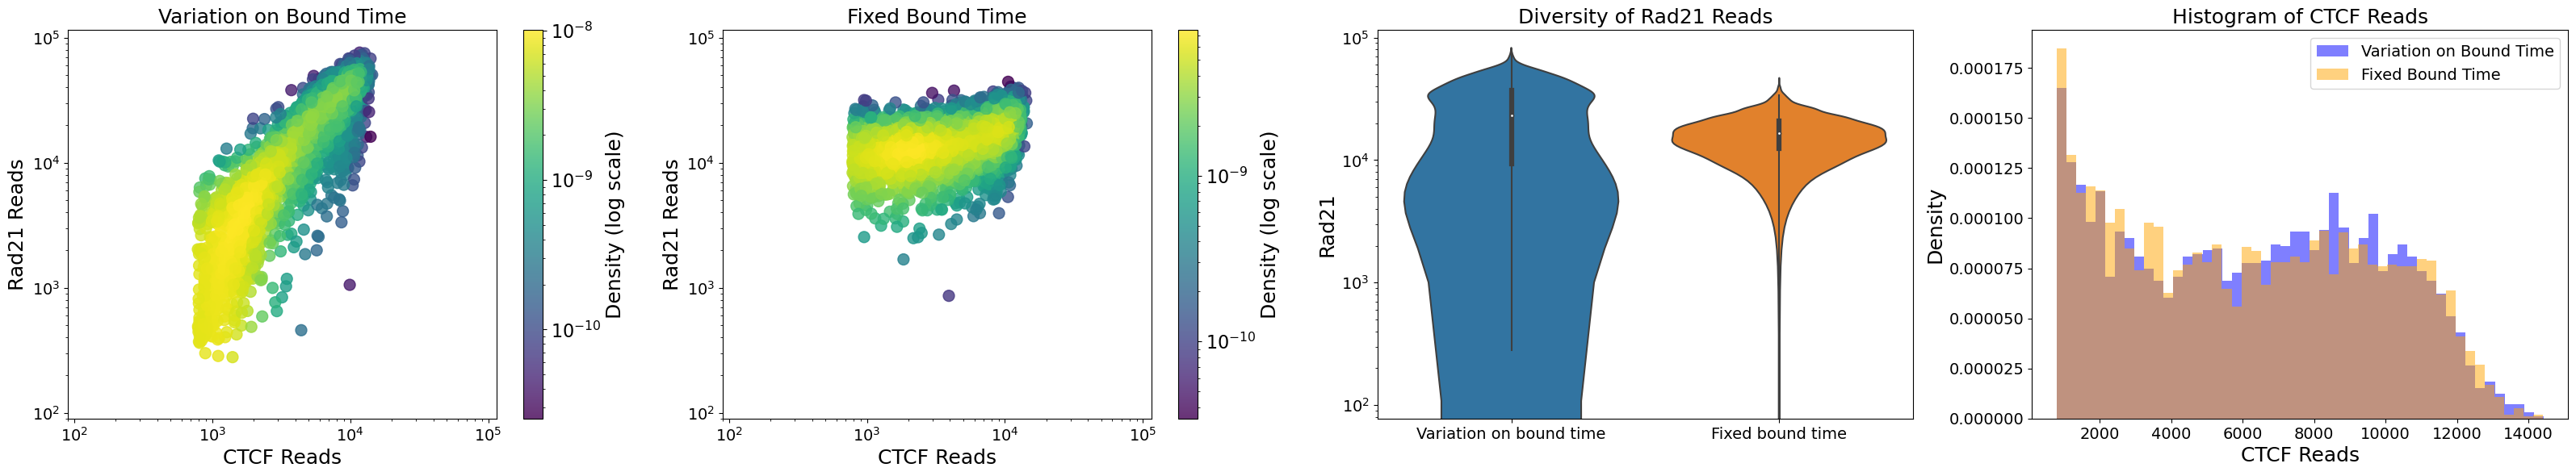

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Load your datasets
file1 = pd.read_csv('Rad21_vs_ctcf_reads_newtot.csv')
file2 = pd.read_csv('Rad21_vs_ctcf_reads_confboundtime_unboundchange_newtot.csv')

# Optional: If Rad21 needs to be divided by 2 (as in earlier examples)
file1['Rad21'] = file1['Rad21']  # / 2
file2['Rad21'] = file2['Rad21']  # / 2

# Remove non-positive values before log scale
x1 = file1['ctcf']
y1 = file1['Rad21']
mask1 = (x1 > 0) & (y1 > 0)
x1 = x1[mask1]
y1 = y1[mask1]

x2 = file2['ctcf']
y2 = file2['Rad21']
mask2 = (x2 > 0) & (y2 > 0)
x2 = x2[mask2]
y2 = y2[mask2]

# Stack and compute point density for both datasets
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)  # Density estimate for each point

xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)  # Density estimate for each point

# Create a new DataFrame combining both, with a label column
file1['Group'] = 'Variation on bound time'
file2['Group'] = 'Fixed bound time'

combined_df = pd.concat([file1[['Rad21', 'Group']], file2[['Rad21', 'Group']]])

# Font sizes (easy to adjust these values)
axis_label_size = 18
tick_label_size = 14
colorbar_tick_size = 16
colorbar_label_size = 18  # Adjust the font size for the colorbar label
title_size = 18

# Set up a 1x4 grid of subplots (add an extra column for the histogram)
fig, axes = plt.subplots(1, 4, figsize=(32, 6))

# Scatter plot for df1 (Variation on bound time) on column 1
sc1 = axes[0].scatter(x1, y1, c=z1, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=100, alpha=0.8)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('CTCF Reads', fontsize=axis_label_size)
axes[0].set_ylabel('Rad21 Reads', fontsize=axis_label_size)
axes[0].set_title('Variation on Bound Time', fontsize=title_size)
axes[0].set_xlim(90, 115000)
axes[0].set_ylim(90, 115000)
cbar1 = fig.colorbar(sc1, ax=axes[0], label='Density (log scale)')
cbar1.ax.tick_params(labelsize=colorbar_tick_size)
cbar1.set_label('Density (log scale)', fontsize=colorbar_label_size)  # Set colorbar label font size
axes[0].tick_params(axis='both', labelsize=tick_label_size)

# Scatter plot for df2 (Fixed bound time) on column 2
sc2 = axes[1].scatter(x2, y2, c=z2, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=100, alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('CTCF Reads', fontsize=axis_label_size)
axes[1].set_ylabel('Rad21 Reads', fontsize=axis_label_size)
axes[1].set_title('Fixed Bound Time', fontsize=title_size)
axes[1].set_xlim(90, 115000)
axes[1].set_ylim(90, 115000)
cbar2 = fig.colorbar(sc2, ax=axes[1], label='Density (log scale)')
cbar2.ax.tick_params(labelsize=colorbar_tick_size)
cbar2.set_label('Density (log scale)', fontsize=colorbar_label_size)  # Set colorbar label font size
axes[1].tick_params(axis='both', labelsize=tick_label_size)

# Violin plot in column 3
sns.violinplot(data=combined_df, x='Group', y='Rad21', ax=axes[2], scale='width')
axes[2].set_yscale('log')
axes[2].set_xlabel('', fontsize=axis_label_size)
axes[2].set_ylabel('Rad21', fontsize=axis_label_size)
axes[2].set_title('Diversity of Rad21 Reads', fontsize=title_size)
axes[2].tick_params(axis='both', labelsize=tick_label_size)

# Histogram for CTCF Reads in column 4
axes[3].hist(x1, bins=50, alpha=0.5, label='Variation on Bound Time', color='blue', density=True)
axes[3].hist(x2, bins=50, alpha=0.5, label='Fixed Bound Time', color='orange', density=True)
axes[3].set_xlabel('CTCF Reads', fontsize=axis_label_size)
axes[3].set_ylabel('Density', fontsize=axis_label_size)
axes[3].set_title('Histogram of CTCF Reads', fontsize=title_size)
axes[3].legend(loc='upper right', fontsize=tick_label_size)
axes[3].tick_params(axis='both', labelsize=tick_label_size)

# Adjust layout for better spacing
plt.tight_layout()

# Save and show plot
plt.savefig('summary_with_histogram.pdf', dpi=500)
plt.show()



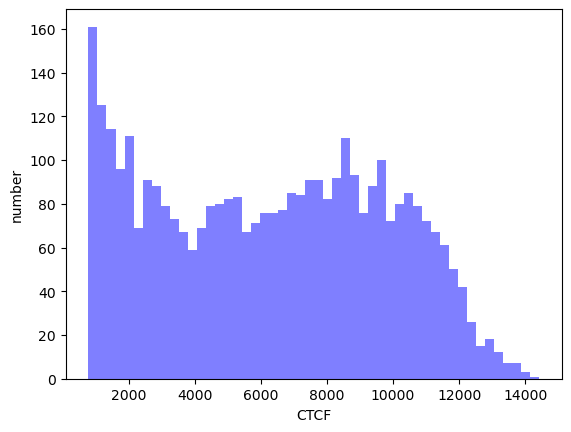

In [32]:
plt.hist(x1, bins=50, alpha=0.5, label='Variation on Bound Time', color='blue')
plt.ylabel('number')
plt.xlabel('CTCF')
plt.show()

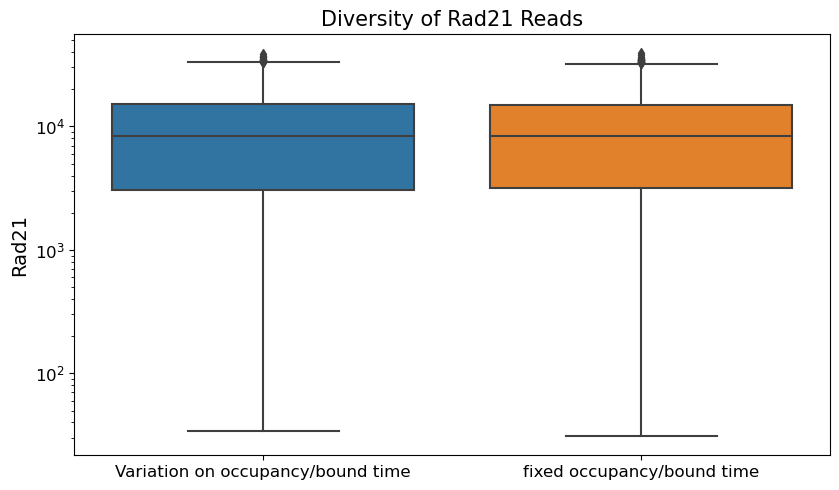

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your datasets
df1 = pd.read_csv('Rad21_vs_ctcf_reads-Copy1.csv')
df2 = pd.read_csv('Rad21_vs_ctcf_reads_confbound.csv')

# Optional: If Rad21 needs to be divided by 2 (as in earlier examples)
df1['Rad21'] = df1['Rad21'] / 2
df2['Rad21'] = df2['Rad21'] / 2

# Create a new DataFrame combining both, with a label column
df1['Group'] = 'Variation on occupancy/bound time'
df2['Group'] = 'fixed occupancy/bound time'

# Combine into one DataFrame for plotting
combined_df = pd.concat([df1[['Rad21', 'Group']], df2[['Rad21', 'Group']]])

# Plot
plt.figure(figsize=(8.5, 5))
sns.boxplot(data=combined_df, x='Group', y='Rad21')

plt.yscale('log')  # If needed to show spread better
plt.ylabel('Rad21', fontsize=14)
plt.xlabel('', fontsize=14)
plt.title('Diversity of Rad21 Reads', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


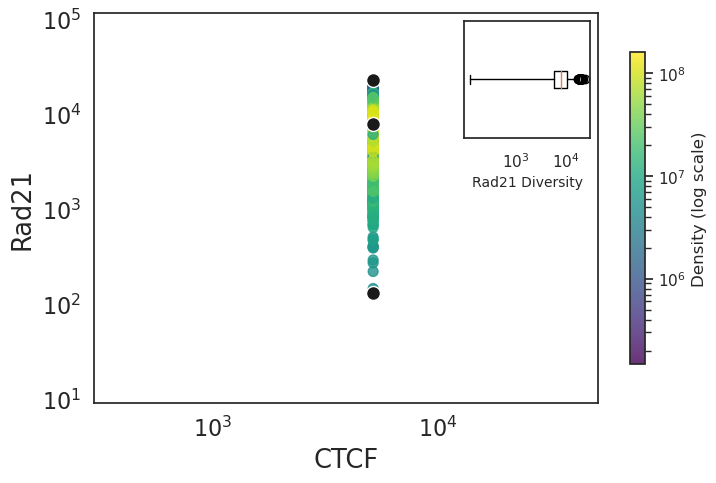

In [45]:
# Add a small inset axis to show y diversity
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.figure(figsize=(7.5, 5))
sc = plt.scatter(x, y, c=z, cmap='viridis', norm=plt.matplotlib.colors.LogNorm(), s=50, alpha=0.8)
plt.colorbar(sc, label='Density (log scale)', shrink=0.8)
plt.scatter(ctcf_s, rad_s, color='k', edgecolors='white', s=100, zorder=5)

plt.xlabel('CTCF', fontsize=18.5)
plt.ylabel('Rad21', fontsize=18.5)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlim(300, 51000)
plt.ylim(9, 115000)

# Add boxplot inset
axins = inset_axes(plt.gca(), width="25%", height="30%", loc='upper right')
axins.boxplot(y, vert=False)
axins.set_xscale('log')
axins.set_yticks([])
axins.set_xlabel('Rad21 Diversity', fontsize=10)

plt.tight_layout()
plt.show()


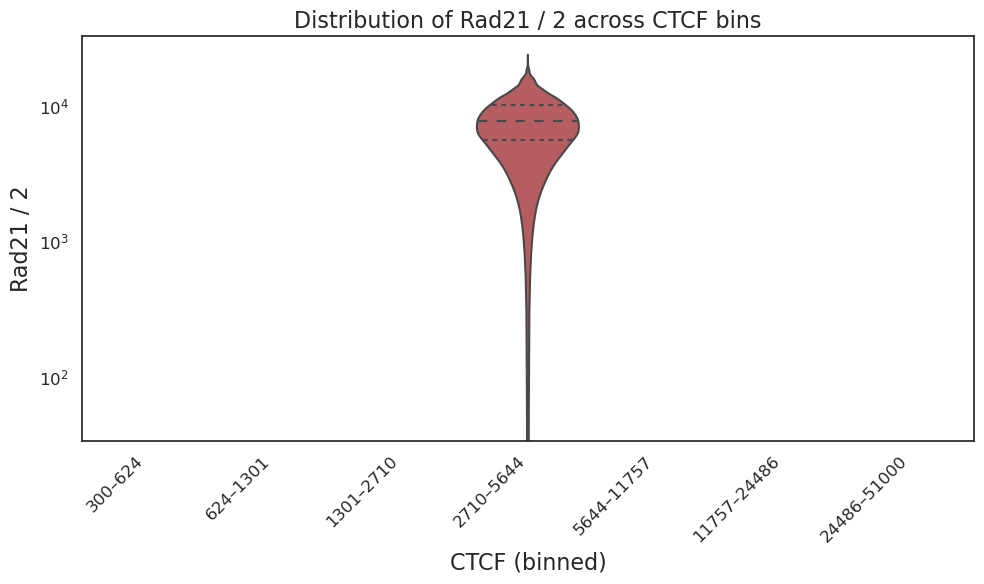

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data
file = df_merged.copy()
file['ctcf'] = file['ctcf']
file['Rad21'] = file['Rad21'] / 2

# Filter out non-positive values
file = file[(file['ctcf'] > 0) & (file['Rad21'] > 0)]

# Bin CTCF into log-spaced bins
bins = np.logspace(np.log10(300), np.log10(51000), num=8)
file['ctcf_bin'] = pd.cut(file['ctcf'], bins=bins, labels=[f'{int(b)}–{int(a)}' for b, a in zip(bins[:-1], bins[1:])])

# Plot violin
plt.figure(figsize=(10, 6))
sns.violinplot(data=file, x='ctcf_bin', y='Rad21', inner='quartile', scale='width')

# Log scale for y-axis
plt.yscale('log')

# Labels and formatting
plt.xlabel('CTCF (binned)', fontsize=16)
plt.ylabel('Rad21 / 2', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Distribution of Rad21 / 2 across CTCF bins', fontsize=16)
plt.tight_layout()
plt.show()


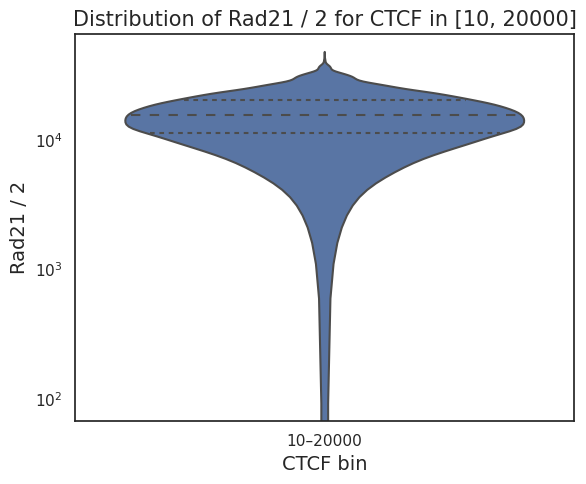

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a CTCF range (adjust as needed)
ctcf_min = 10
ctcf_max = 20000

# Filter for that bin
single_bin = file[(file['ctcf'] >= ctcf_min) & (file['ctcf'] < ctcf_max)]

# Create a dummy column to group by (since we only have one bin)
single_bin['bin_label'] = f'{ctcf_min}–{ctcf_max}'

# Plot violin plot
plt.figure(figsize=(6, 5))
sns.violinplot(data=single_bin, x='bin_label', y='Rad21', inner='quartile', scale='width')

plt.yscale('log')
plt.xlabel('CTCF bin', fontsize=14)
plt.ylabel('Rad21 / 2', fontsize=14)
plt.title(f'Distribution of Rad21 / 2 for CTCF in [{ctcf_min}, {ctcf_max}]', fontsize=15)
plt.tight_layout()
plt.show()


In [13]:
file

,Rad21,ctcf
0,15792,889.285714
1,20315,5170.033670
2,88881,13710.914454
3,14126,384.259259
4,52155,7370.656371
...,...,...
783,1274,638.461538
784,28449,6872.100515
785,20713,4556.862745
786,13048,6052.083333


In [14]:
file = pd.read_csv('Rad21_vs_ctcf_reads.csv')
file

,Rad21,ctcf
0,13831,4772.727273
1,14207,9044.554455
2,11451,10369.001919
3,77144,14046.357616
4,292,1294.520548
...,...,...
7449,17567,9585.120643
7450,22122,11318.319838
7451,19747,4129.573171
7452,14752,11490.213523
